In [1]:
import os
import sys
from pathlib import Path
import logging
import pandas as pd
from dotenv import load_dotenv
import networkx as nx
from typing import Tuple, Any, List, Dict
from IPython.display import IFrame, display, HTML
import json
import math
# Reduce logging noise
logging.getLogger().setLevel(logging.WARNING)

ROOT_DIR = Path(os.getcwd())
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

from graph_generation.sbfl.extractor import ExtractionResult
from visualization.graph_plots import plot_json_graph
from cut_algorithms.boykov_jolly import BoykovJollyCut
from cut_algorithms.data_parsers import read_call_graph
from cut_algorithms.data_parsers import compute_method_tarantula


In [2]:
base_path = ROOT_DIR / "data" / "defects4j"

In [3]:
import ast
def get_buggy_nodes(proj, bugid):
    df_gt= pd.read_csv("/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/ground_truth.csv")
    buggy_nodes = df_gt[df_gt['project']==proj][df_gt['bug_id'] == bugid].buggy_nodes.values[0]
    return ast.literal_eval(buggy_nodes)

In [4]:
bugs = sorted([item for item in base_path.iterdir() if item.is_dir()])
bugs

[PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_1'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_10'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_11'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_12'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_13'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_14'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_15'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagat

In [5]:
instance = bugs[0]
project, bug_id = str(instance).split("/")[-1].split("_")
project, bug_id


('Chart', '1')

In [6]:
def load_pregen_data(project: str, bug_id: str) -> Tuple[ExtractionResult, Path]:
    """Loads pre-generated extraction data instead of running D4J in real-time."""
    data_dir = ROOT_DIR / "data" / "defects4j" / f"{project}_{bug_id}"
    
    if not data_dir.exists():
        raise FileNotFoundError(f"Pre-generated data not found at {data_dir}")
        
    metrics_csv = data_dir / "sbfl_metrics.csv"
    graph_json = data_dir / "call_graph.json"
    buggy_txt = data_dir / "buggy_methods.txt"
    
    sbfl_metrics = pd.read_csv(metrics_csv).to_dict(orient="records")
    
    with open(buggy_txt, 'r') as f:
        buggy_methods = [line.strip() for line in f if line.strip()]
        
    res = ExtractionResult(
        graph_json=str(graph_json),
        sbfl_metrics=sbfl_metrics,
        buggy_methods=buggy_methods
    )
    
    return res

In [7]:
def json_to_digraph(graph_json: str) -> nx.DiGraph:
    with open(graph_json, 'r') as f:
        graph_data = json.load(f)

    G = nx.DiGraph()
    for edge in graph_data['edges']:
        caller = edge['caller'].replace('$', '.')
        callee = edge['callee'].replace('$', '.')
        G.add_edge(caller, callee, weight=float(edge['frequency']))
    
    for node in graph_data.get('nodes', []):
        n_clean = node.replace('$', '.')
        if n_clean not in G:
            G.add_node(n_clean)
    return G

In [8]:
extraction_res = load_pregen_data(project, bug_id)

In [9]:
G = json_to_digraph(extraction_res.graph_json)
G

# EDA on Available call graphs

In [10]:
working_instances = {}
for bug in bugs:
    project, bug_id = str(bug).split("/")[-1].split("_")
    graph_json = bug / "call_graph.json"
    buggy_methods = bug / "buggy_methods.txt"
    try:
        with open(graph_json, 'r') as f:
            graph_data = json.load(f)

        buggy_methods = bug / "buggy_methods.txt"
        with open(buggy_methods, 'r', encoding='utf-8') as file:
            buggy_nodes = [line.strip() for line in file if line.strip()]
        
        if graph_data["metadata"]["total_nodes"] > 0:
            graph_data["metadata"]["buggy_nodes"] = buggy_nodes
            graph_data["metadata"]["num_buggy_nodes"] = len(buggy_nodes)
            working_instances[str(bug).split("/")[-1]] = graph_data["metadata"]
    except Exception as e:
        continue

In [11]:
df_active = pd.DataFrame(working_instances).T
split_index = df_active.index.str.split('_', expand=True)
df_active['project'] = split_index.get_level_values(0)
df_active['bug_id'] = split_index.get_level_values(1)

df_active['bug_id'] = pd.to_numeric(df_active['bug_id'])
df_active

,total_nodes,total_edges,buggy_nodes,num_buggy_nodes,project,bug_id
Chart_1,198,239,[org.jfree.chart.renderer.category.AbstractCat...,1,Chart,1
Chart_11,7,6,[org.jfree.chart.util.ShapeUtilities#equal],1,Chart,11
Chart_12,184,239,[org.jfree.chart.plot.MultiplePiePlot#Multiple...,1,Chart,12
Chart_13,64,83,[org.jfree.chart.block.BorderArrangement#Range],1,Chart,13
Chart_14,915,1530,[org.jfree.chart.plot.XYPlot#removeRangeMarker...,4,Chart,14
...,...,...,...,...,...,...
Time_23,468,724,[org.joda.time.DateTimeZone#getConvertedId],1,Time,23
Time_24,780,1588,[org.joda.time.format.DateTimeParserBucket#com...,1,Time,24
Time_25,651,1234,[org.joda.time.DateTimeZone#getOffsetFromLocal],1,Time,25
Time_26,651,1234,[org.joda.time.chrono.ZonedChronology#roundCei...,7,Time,26


In [12]:
df_active["project"].value_counts()

project
Jsoup              92
Math               63
Compress           37
JacksonDatabind    29
JacksonCore        26
Chart              25
Lang               24
JxPath             22
Collections        20
Gson               18
Codec              17
Csv                16
Mockito            14
Time               14
Cli                 6
JacksonXml          6
Closure             2
Name: count, dtype: int64

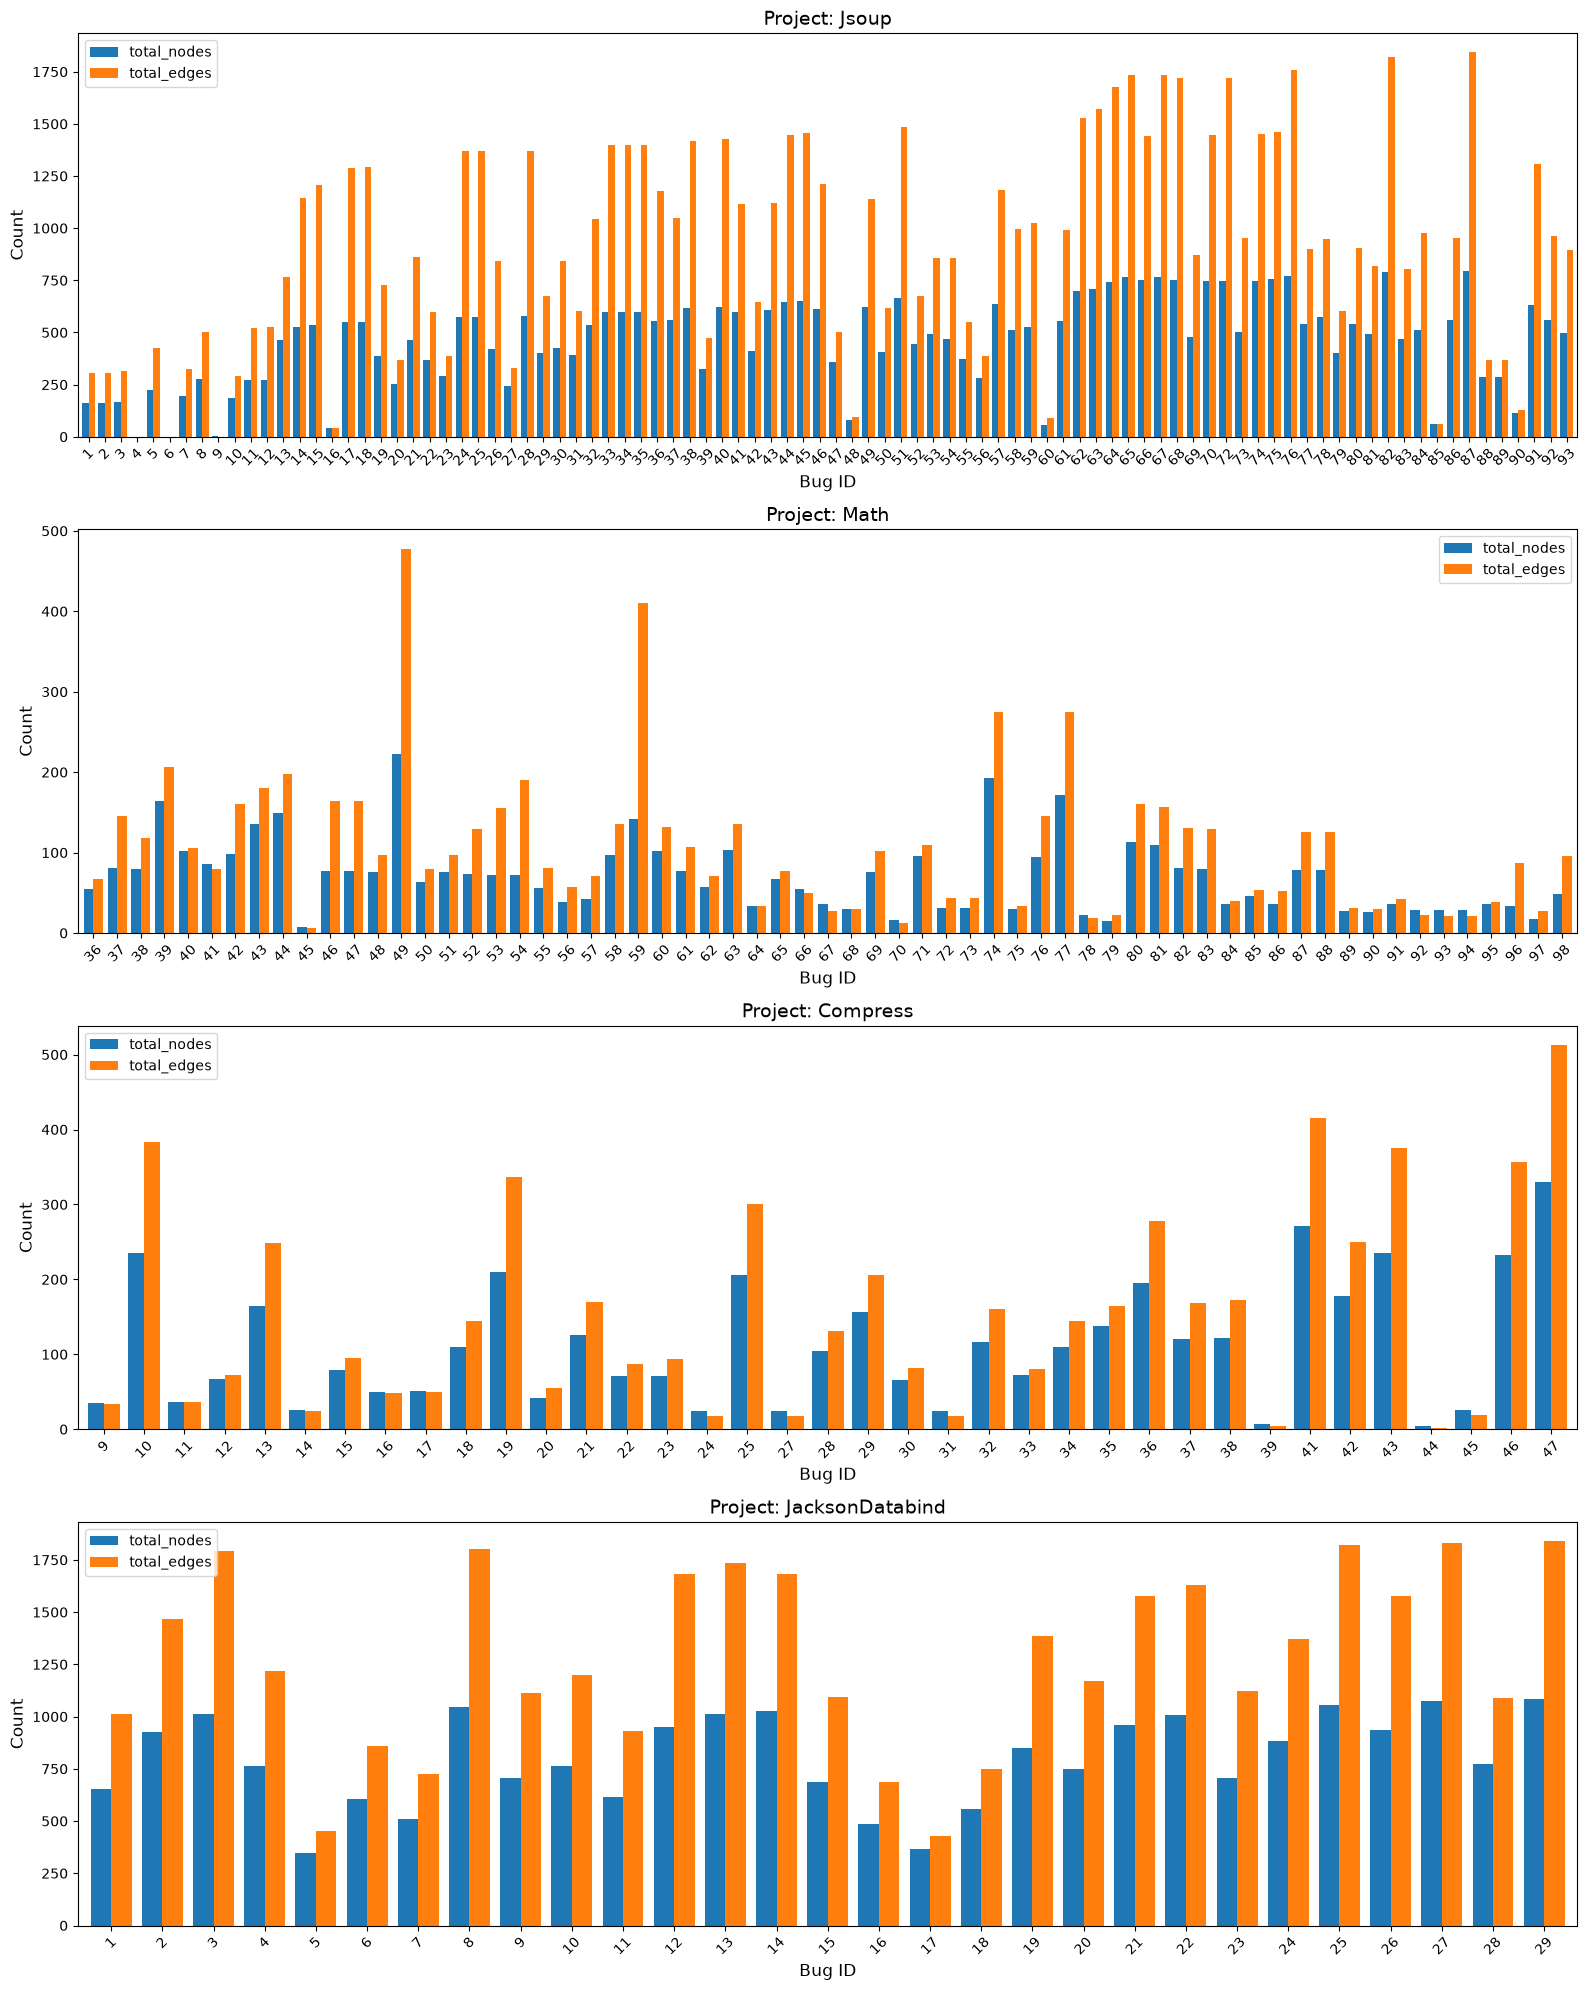

In [13]:
import matplotlib.pyplot as plt

# Get the top 4 projects
top_4_projects = df_active['project'].value_counts().head(4).index

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(16, 20))

for i, project_name in enumerate(top_4_projects):
    # Filter data and sort by bug_id so the X-axis is in numerical order
    project_data = df_active[df_active['project'] == project_name].sort_values('bug_id')
    
    # We temporarily set 'bug_id' as the index so pandas uses it for the X-axis labels
    project_data_indexed = project_data.set_index('bug_id')
    
    # Plot the bar chart
    project_data_indexed[['total_nodes', 'total_edges']].plot(
        kind='bar', 
        ax=axes[i], 
        width=0.8,
        color=['#1f77b4', '#ff7f0e']
    )
    
    axes[i].set_title(f'Project: {project_name}', fontsize=14)
    axes[i].set_xlabel('Bug ID', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # Make sure we don't crowd the x-axis labels
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
extraction_res.sbfl_metrics

[{'Method': 'org.jfree.chart.BufferedImageRenderingSource#BufferedImageRenderingSource(java.awt.image.BufferedImage)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.BufferedImageRenderingSource#createGraphics2D()',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.BufferedImageRenderingSource#getSelectionState(org.jfree.data.general.Dataset)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.BufferedImageRenderingSource#putSelectionState(org.jfree.data.general.Dataset,org.jfree.data.general.DatasetSelectionState)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.ChartColor#ChartColor(int,int,int)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.ChartColor#createDefaultPaintArray()',
  'Ochiai': 0.0576390417704235,
  'Tarantula': 0.8797113071371291,
  'Fail_Executed': 1},
 {'Method': '

In [15]:
def plot_project_distribution(project_name, df):
    df_proj = df[df['project'] == project_name]
    plt.figure(figsize=(10, 6))

    plt.hist(df_proj['total_nodes'], bins=20, alpha=0.5, label='Total Nodes', edgecolor='black')
    plt.hist(df_proj['total_edges'], bins=20, alpha=0.5, label='Total Edges', edgecolor='black')
    
    plt.title(f'{project_name}')
    plt.xlabel('Count (Nodes/Edges)', fontsize=12)
    plt.ylabel('Frequency (Number of Instances)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


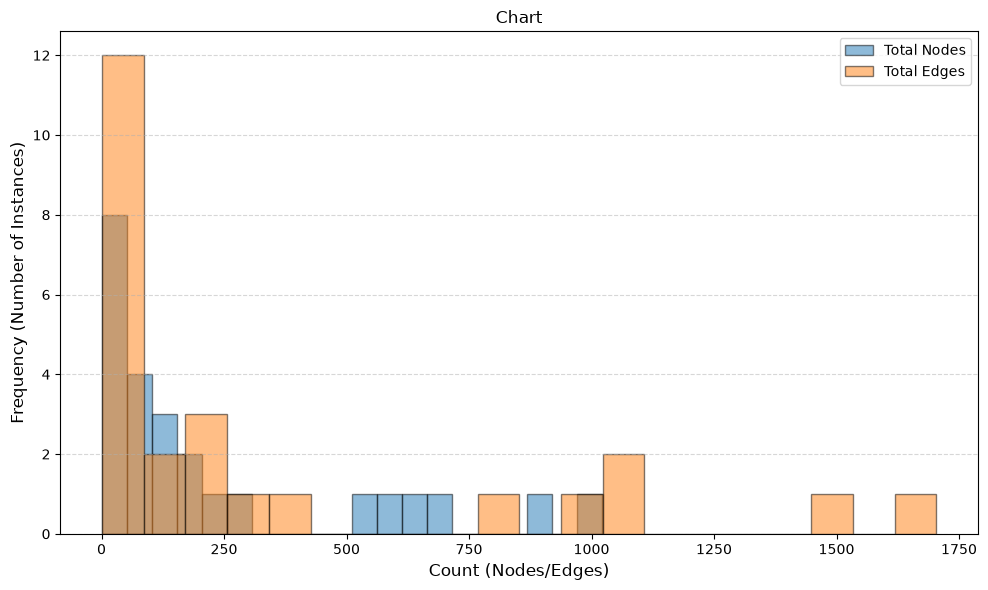

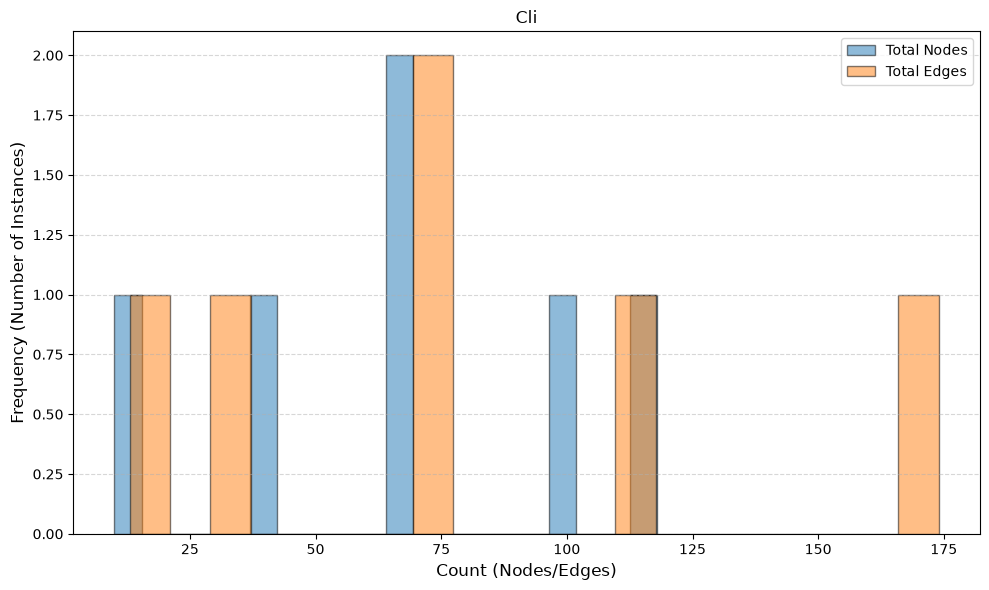

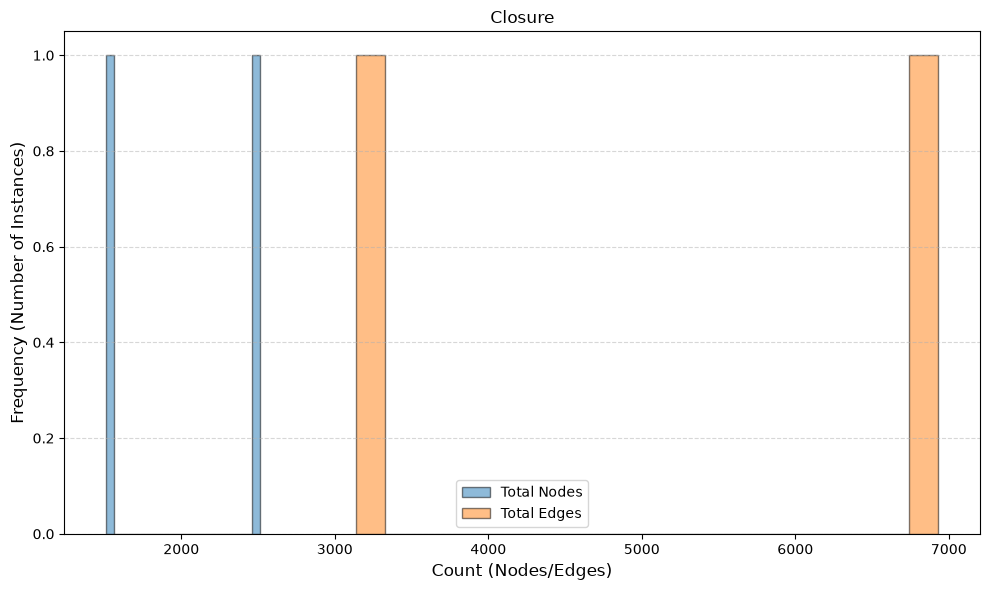

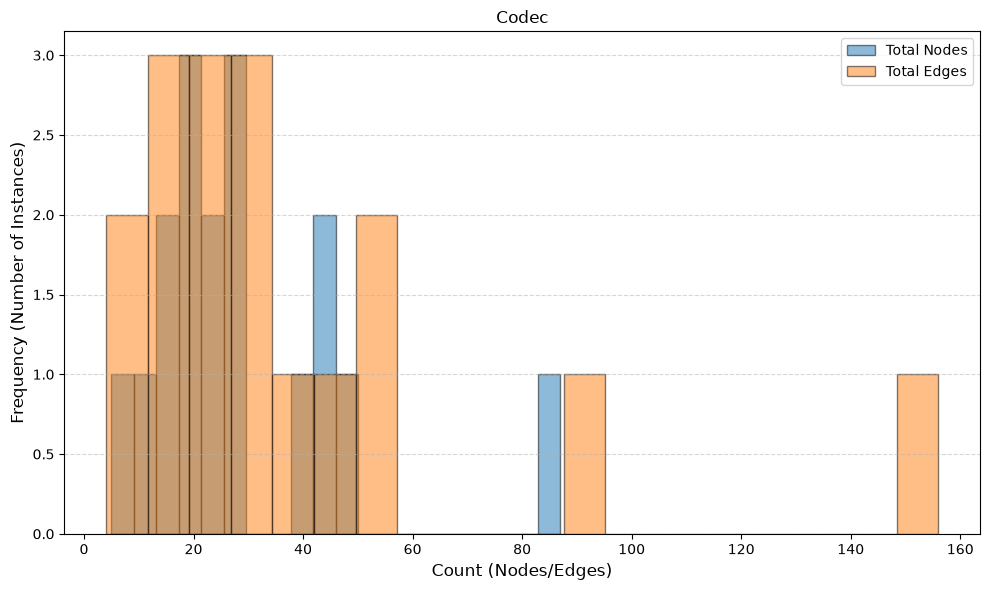

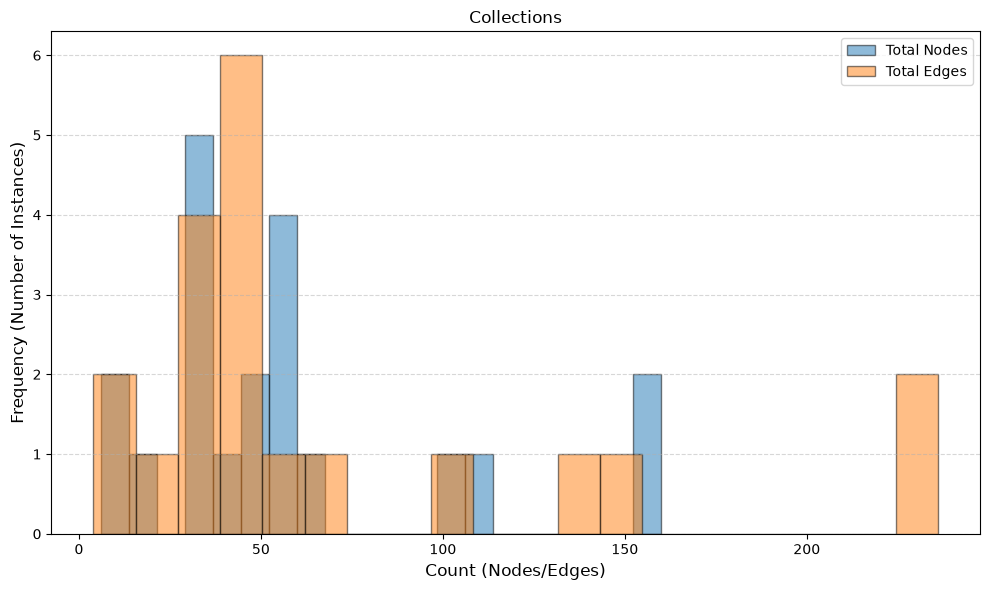

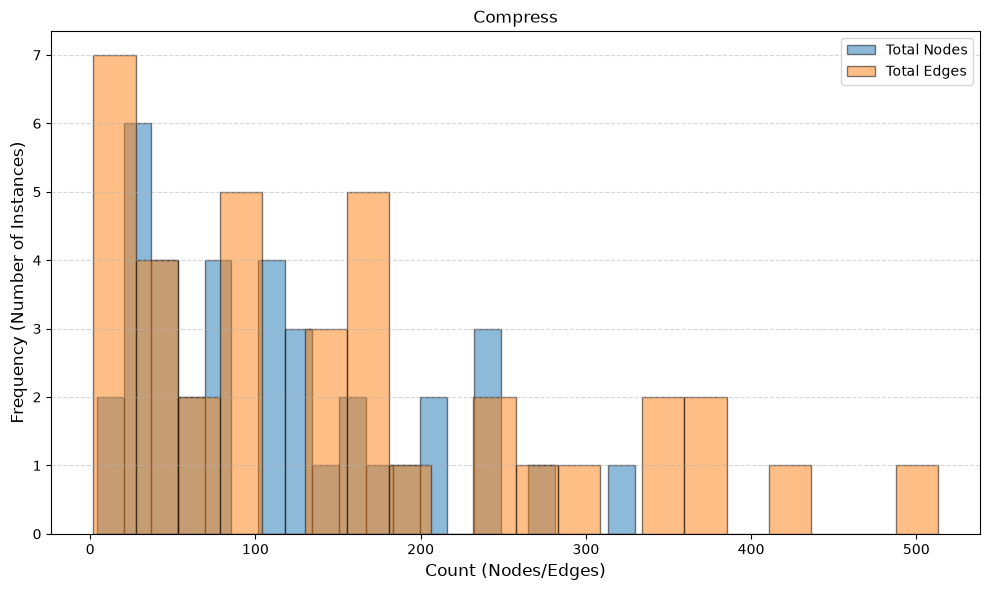

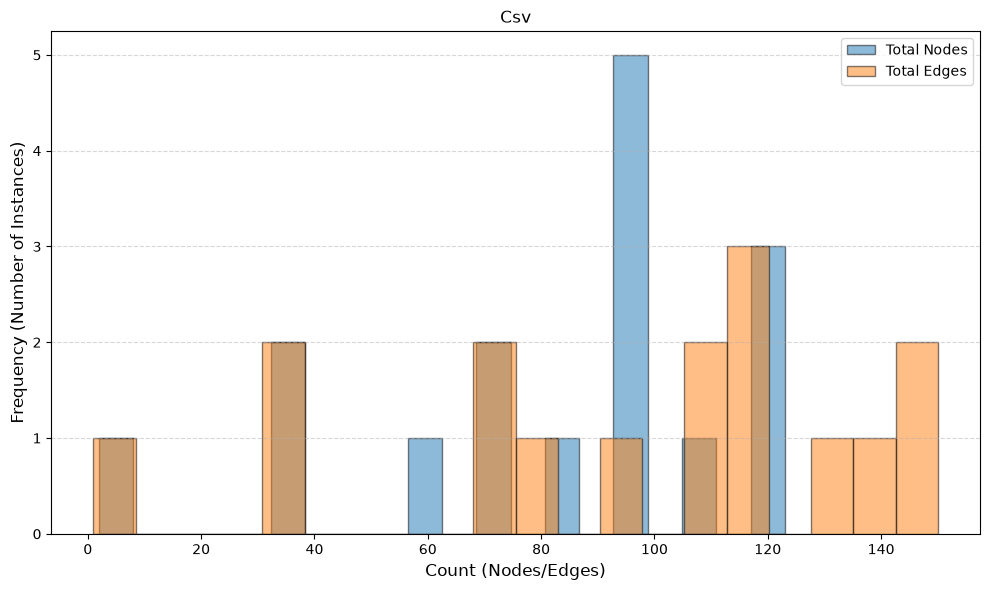

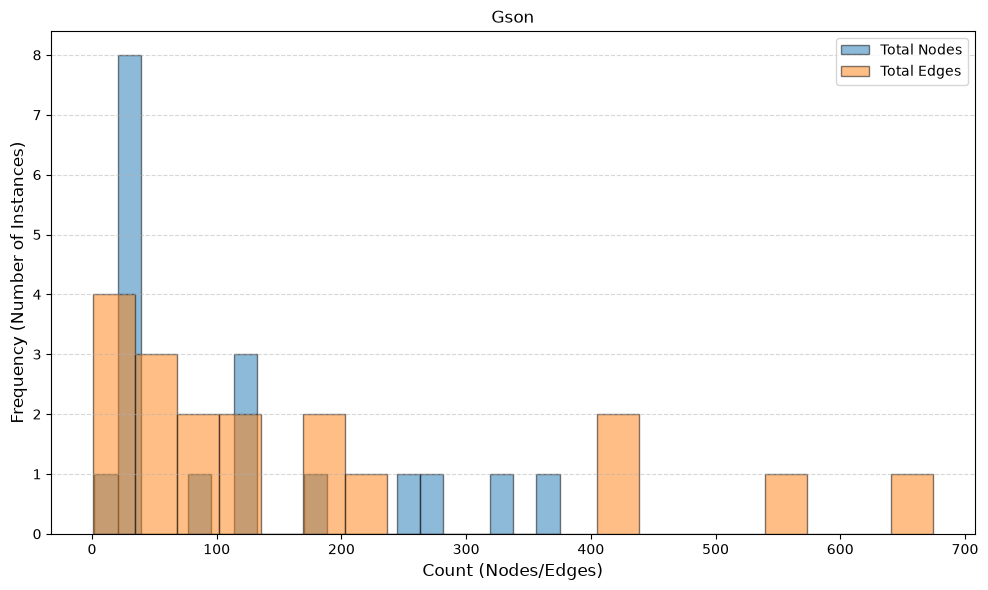

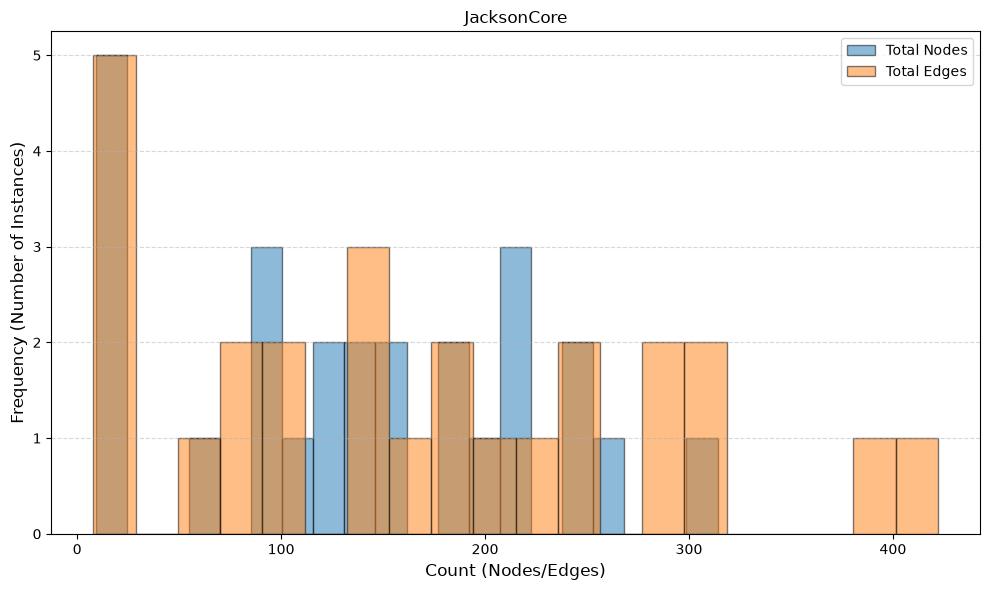

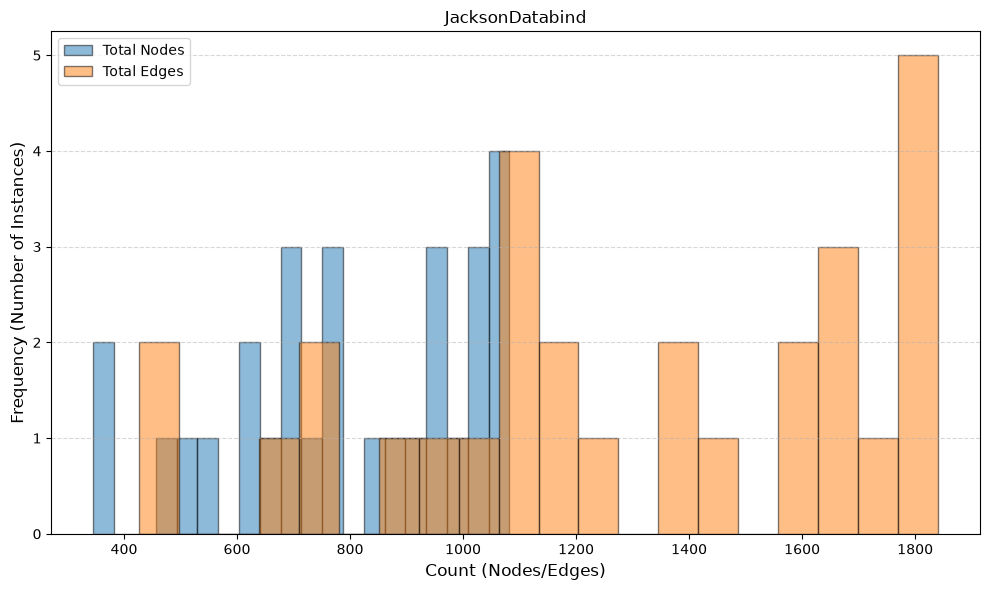

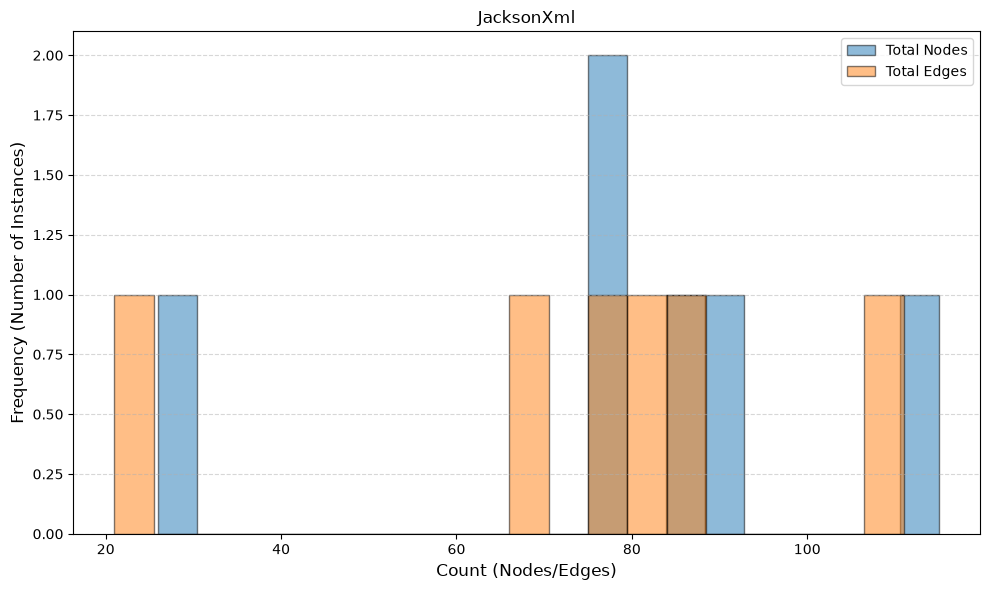

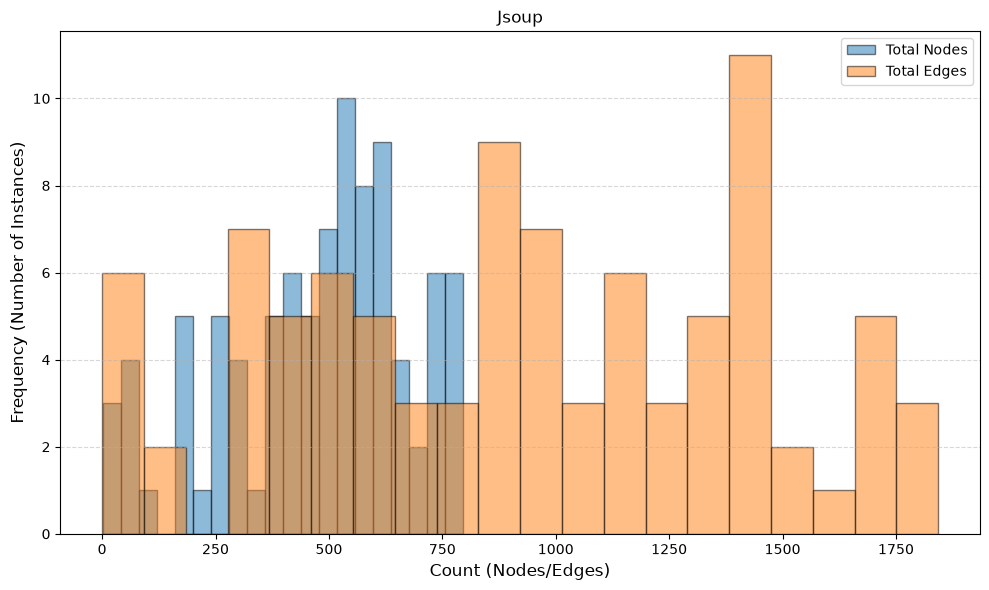

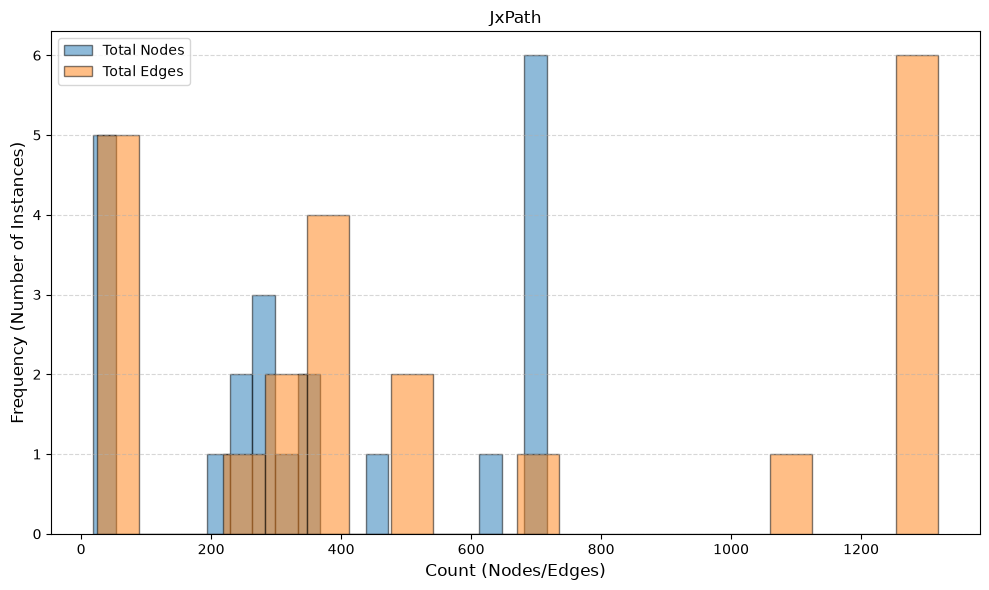

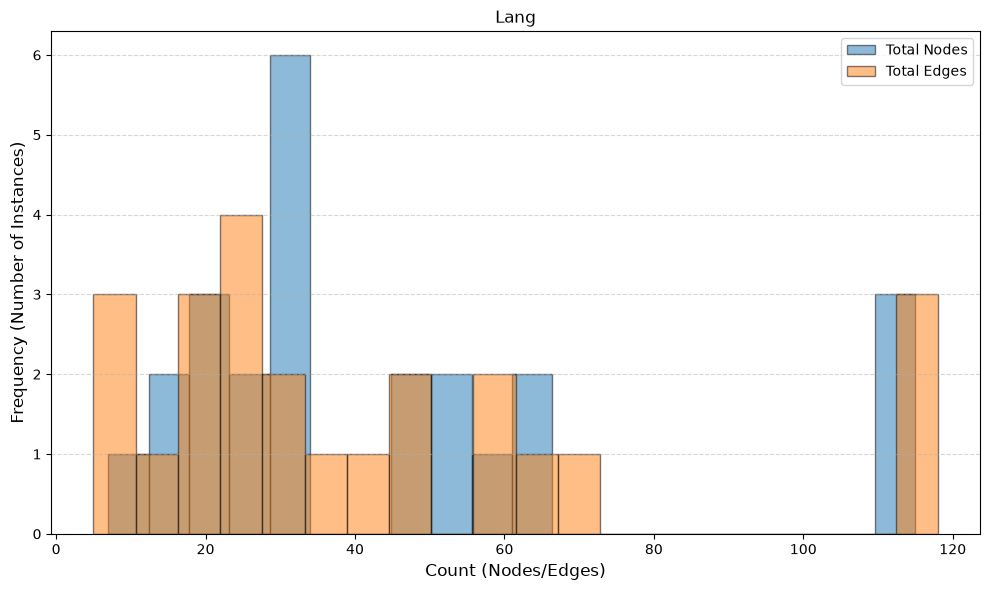

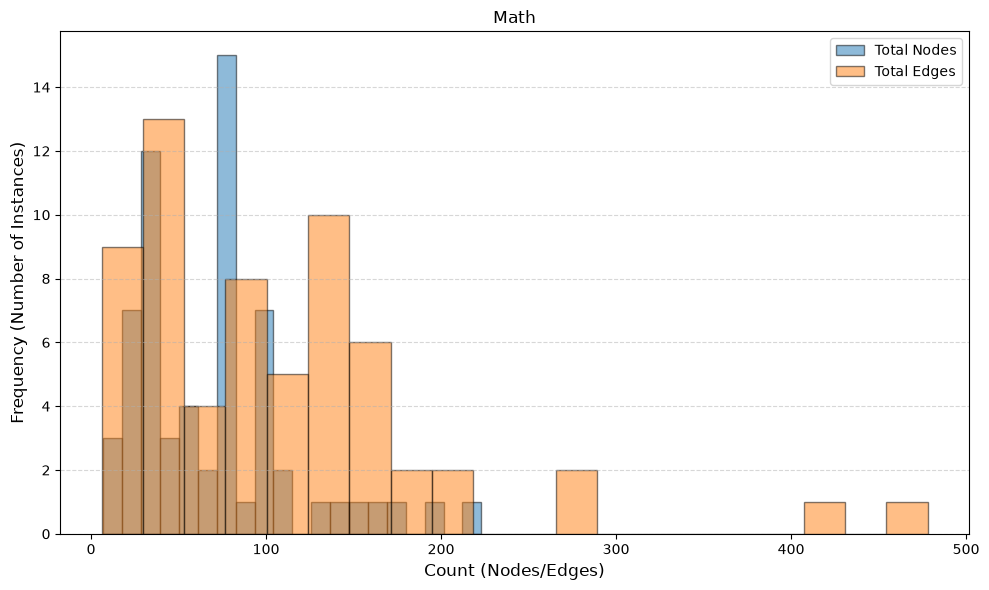

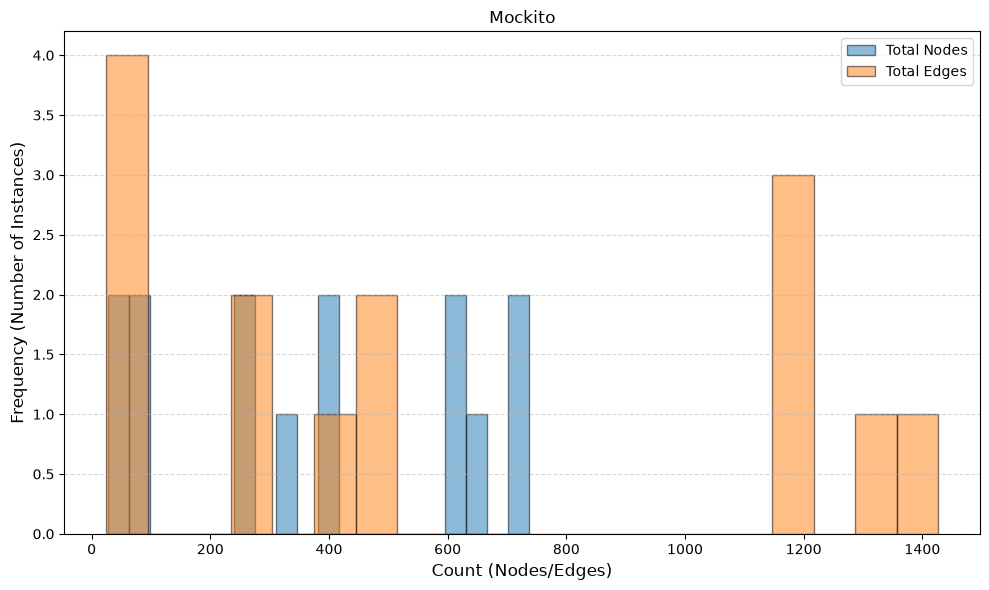

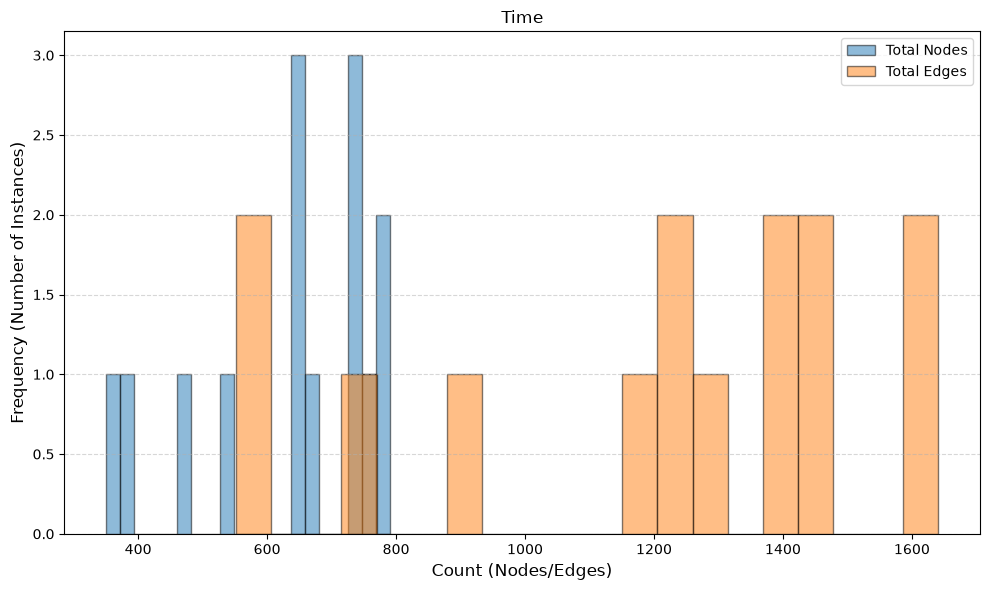

In [16]:
for project in df_active.project.unique():
    plot_project_distribution(project, df_active)

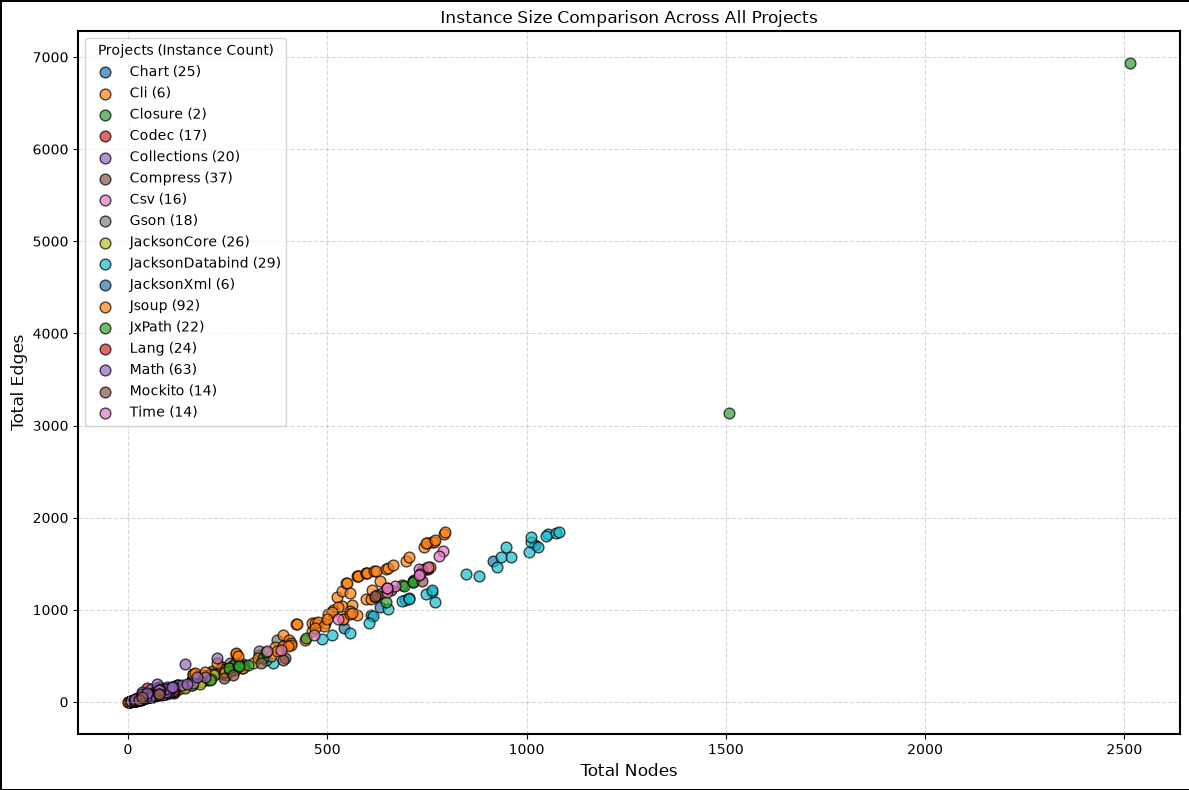

In [17]:
def plot_project_comparison_scatter(df):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for project_name, group_data in df.groupby('project'):
        ax.scatter(
            group_data['total_nodes'], 
            group_data['total_edges'], 
            alpha=0.7, 
            label=f"{project_name} ({len(group_data)})", 
            edgecolors='black', # Crisp borders on the dots
            linewidth=1,
            s=60 # Slightly larger dots for visibility
        )
    
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    plt.title('Instance Size Comparison Across All Projects')
    plt.xlabel('Total Nodes', fontsize=12)
    plt.ylabel('Total Edges', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.legend(title='Projects (Instance Count)', loc='upper left')
    
    plt.tight_layout()
    plt.show()

plot_project_comparison_scatter(df_active)

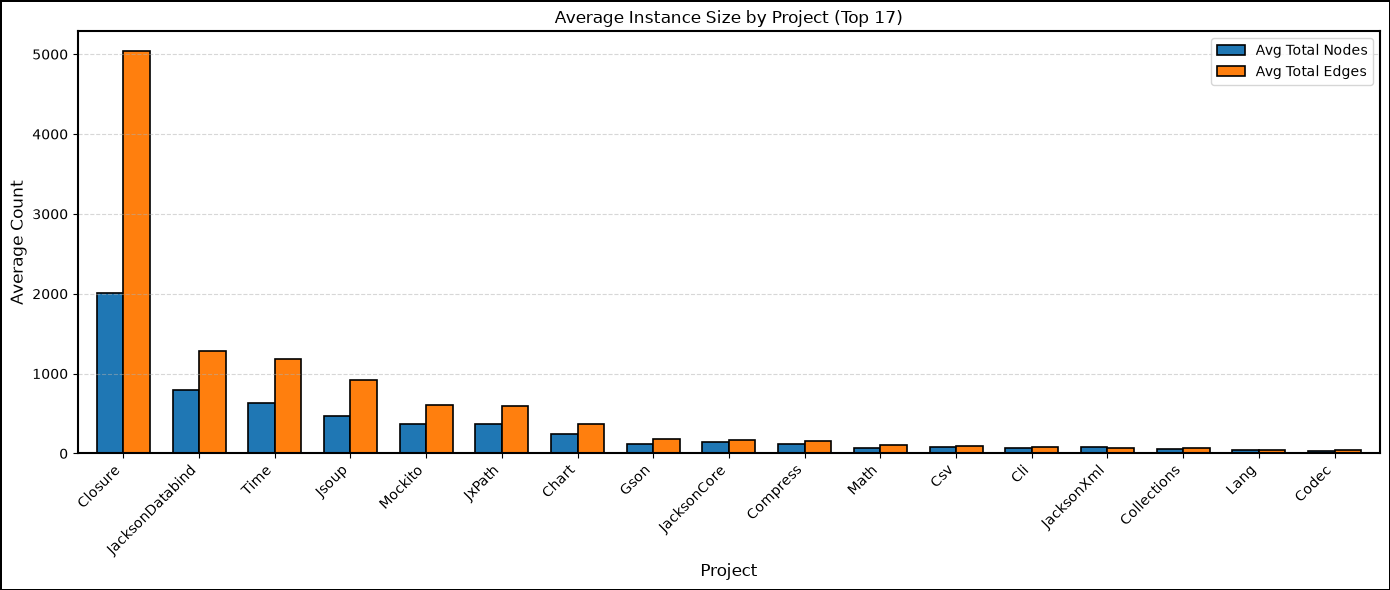

In [18]:
def plot_project_comparison_averages(df):
    df_grouped = df.groupby('project')[['total_nodes', 'total_edges']].mean()
    df_grouped = df_grouped.sort_values('total_edges', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    df_grouped.plot(
        kind='bar', 
        ax=ax,
        width=0.7, 
        color=['#1f77b4', '#ff7f0e'],
        edgecolor='black', # Crisp bar borders
        linewidth=1.2
    )
    
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
        
    plt.title(f'Average Instance Size by Project (Top {len(df_grouped)})')
    plt.xlabel('Project', fontsize=12)
    plt.ylabel('Average Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(['Avg Total Nodes', 'Avg Total Edges'])
    
    plt.tight_layout()
    plt.show()
plot_project_comparison_averages(df_active)

In [19]:
df_active['num_buggy_nodes'].value_counts()

num_buggy_nodes
1     297
2      66
3      26
4      12
0      11
7       5
6       5
5       3
10      2
15      1
8       1
19      1
13      1
Name: count, dtype: int64

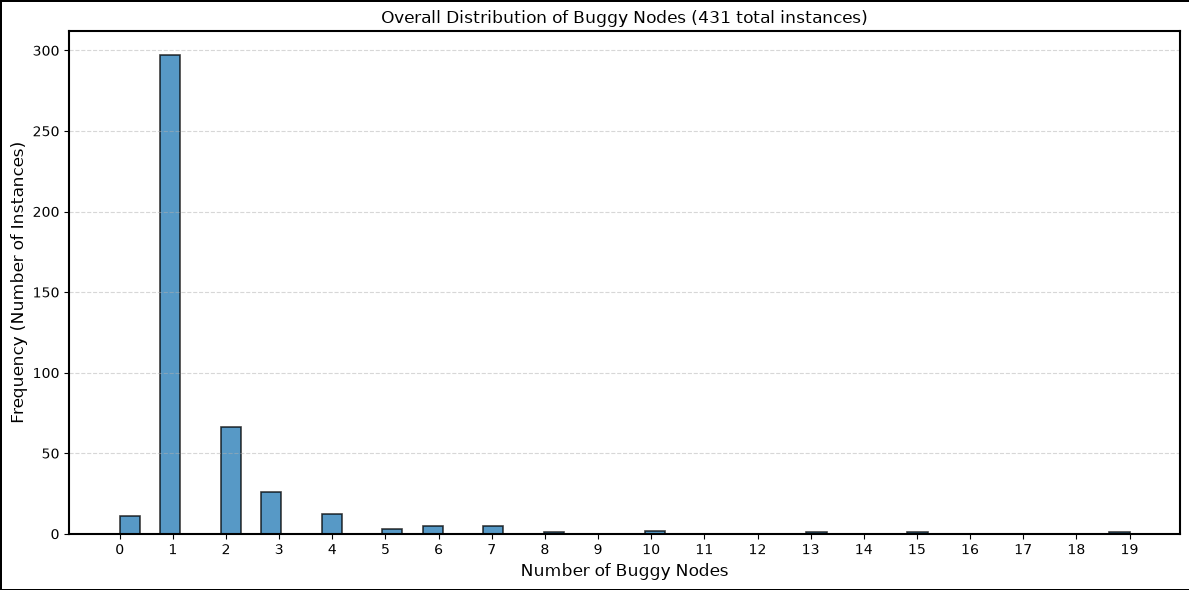

In [20]:
import matplotlib.pyplot as plt

def plot_overall_buggy_nodes_histogram(df, num_bins=40):
    # 1. Extract the data and drop any missing values
    data = df['num_buggy_nodes'].dropna()
    
    # 2. Create the plot setup
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 3. Plot the histogram
    ax.hist(
        data, 
        bins=num_bins, 
        edgecolor='black', 
        linewidth=1.2, 
        alpha=0.75
    )
    
    # 4. Add the thick outer frame border
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    
    # 5. Make the inner plot box slightly thicker to match
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    # 6. Standard Formatting
    plt.title(f'Overall Distribution of Buggy Nodes ({len(data)} total instances)')
    plt.xlabel('Number of Buggy Nodes', fontsize=12)
    plt.ylabel('Frequency (Number of Instances)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    min_x = int(data.min())
    max_x = int(data.max())
    plt.xticks(range(min_x, max_x + 1))
    
    plt.tight_layout()
    plt.show()


plot_overall_buggy_nodes_histogram(df_active, num_bins=50)

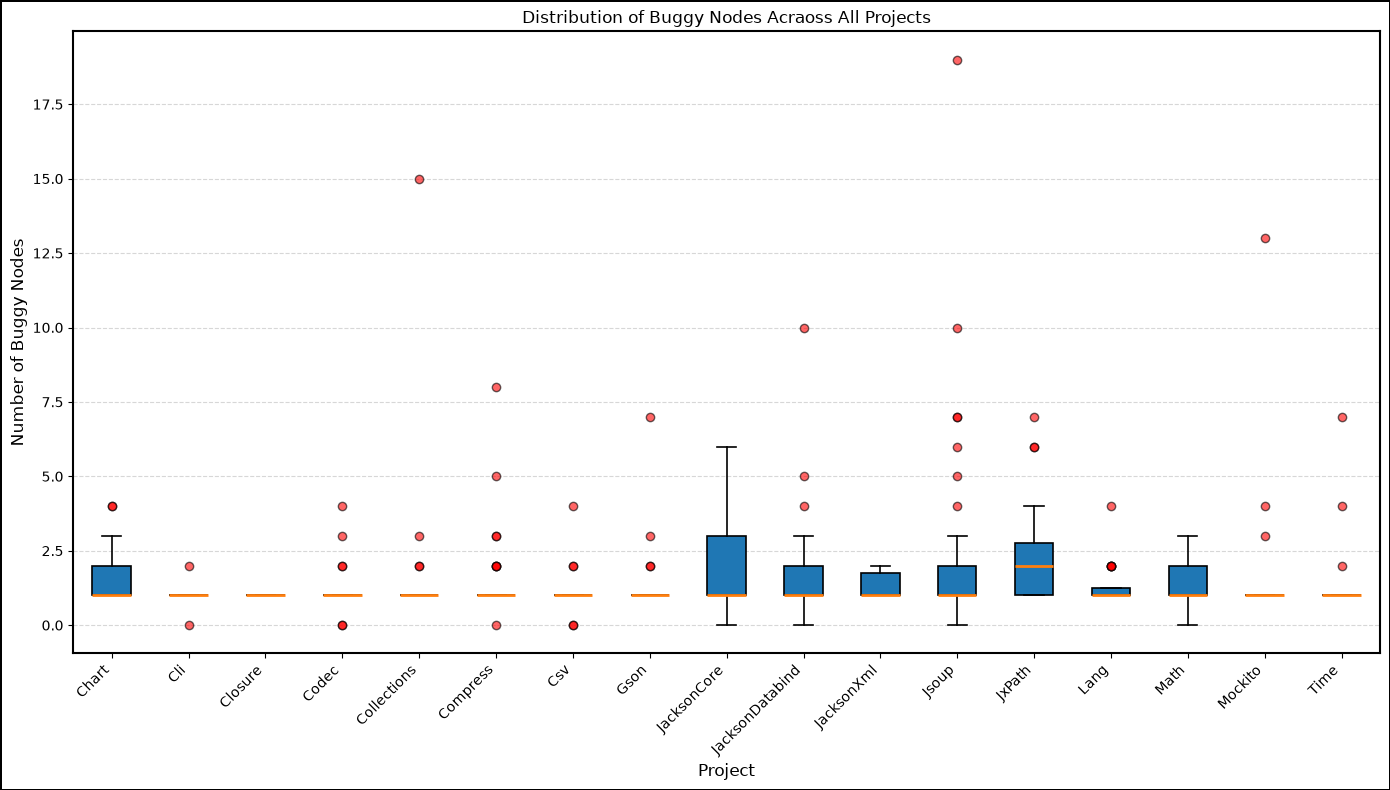

In [21]:
def plot_buggy_nodes_distribution(df):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    projects = sorted(df['project'].unique())
    
    data_to_plot = [df[df['project'] == p]['num_buggy_nodes'].dropna() for p in projects]
    ax.boxplot(
        data_to_plot, 
        tick_labels=projects,
        patch_artist=True, 
        boxprops=dict(facecolor='#1f77b4', color='black', linewidth=1.2), 
        medianprops=dict(color='#ff7f0e', linewidth=2),                   
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.6) 
    )
    
    # Outer frame and inner spines
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
        
    # Formatting
    plt.title('Distribution of Buggy Nodes Acraoss All Projects')
    plt.xlabel('Project', fontsize=12)
    plt.ylabel('Number of Buggy Nodes', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_buggy_nodes_distribution(df_active)

# Subset selection

Use only single bug instances

In [22]:
single_bug_instances = df_active[df_active['num_buggy_nodes']==1]
single_bug_instances

,total_nodes,total_edges,buggy_nodes,num_buggy_nodes,project,bug_id
Chart_1,198,239,[org.jfree.chart.renderer.category.AbstractCat...,1,Chart,1
Chart_11,7,6,[org.jfree.chart.util.ShapeUtilities#equal],1,Chart,11
Chart_12,184,239,[org.jfree.chart.plot.MultiplePiePlot#Multiple...,1,Chart,12
Chart_13,64,83,[org.jfree.chart.block.BorderArrangement#Range],1,Chart,13
Chart_17,110,157,[org.jfree.data.time.TimeSeries#delete],1,Chart,17
...,...,...,...,...,...,...
Time_22,650,1191,[org.joda.time.base.BasePeriod#BasePeriod],1,Time,22
Time_23,468,724,[org.joda.time.DateTimeZone#getConvertedId],1,Time,23
Time_24,780,1588,[org.joda.time.format.DateTimeParserBucket#com...,1,Time,24
Time_25,651,1234,[org.joda.time.DateTimeZone#getOffsetFromLocal],1,Time,25


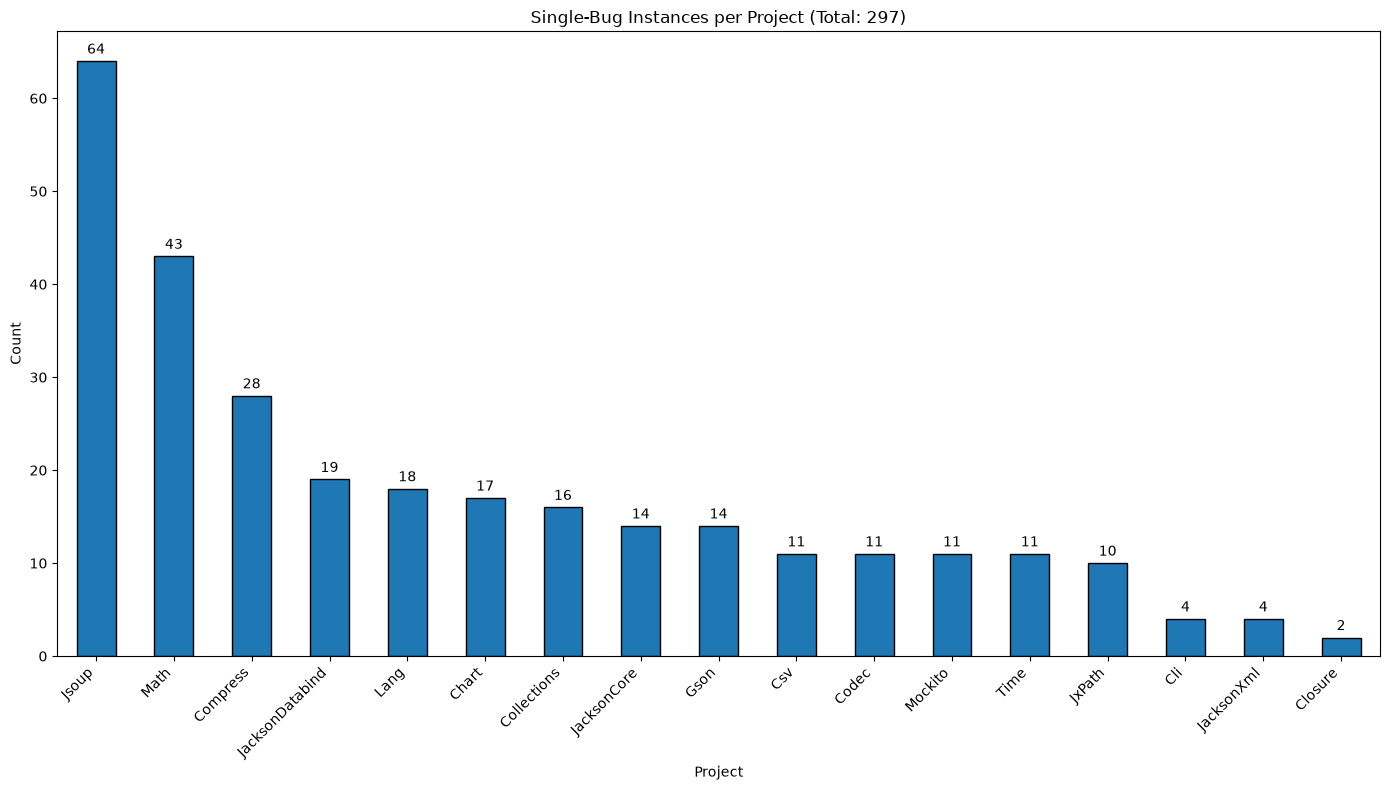

In [23]:
import matplotlib.pyplot as plt

single_bug_counts = single_bug_instances['project'].value_counts()
plt.figure(figsize=(14, 8))

# Save the plot to an 'ax' variable so we can add labels to it
ax = single_bug_counts.plot(kind='bar', edgecolor='black')

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

# Add basic labels
plt.title(f'Single-Bug Instances per Project (Total: {len(single_bug_instances)})')
plt.xlabel('Project')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

# Baselines

In [24]:

def compute_method_tarantula(coverage_df: pd.DataFrame) -> dict[str, float]:
    df = coverage_df
    
    # Aggregate line level to method level
    method_data = {}
    for col in df.columns:
        if col == 'Result':
            continue
        method = map_line_to_method(col)
        if method not in method_data:
            method_data[method] = df[col].copy()
        else:
            method_data[method] = method_data[method] | df[col]
            
    method_df = pd.DataFrame(method_data)
    method_df['Result'] = df['Result']
    
    total_fail = len(method_df[method_df['Result'] == 'Fail'])
    total_pass = len(method_df[method_df['Result'] == 'Pass'])
    
    tarantula_scores = {}
    for method in method_df.columns:
        if method == 'Result':
            continue
        cf = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Fail')])
        cp = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Pass')])
        
        if total_fail == 0 or (cf == 0 and cp == 0):
            tarantula = 0.0
        else:
            fail_ratio = cf / total_fail
            pass_ratio = cp / total_pass if total_pass > 0 else 0.0
            if fail_ratio + pass_ratio == 0:
                tarantula = 0.0
            else:
                tarantula = fail_ratio / (fail_ratio + pass_ratio)
                
        tarantula_scores[method] = float(tarantula)
        
    return tarantula_scores

def map_line_to_method(line_name: str) -> str:
    """Maps a coverage column like 'com.example$App#process(int):30' to 'com.example.App#process(int)'."""
    if "#" not in line_name:
        return line_name.replace('$', '.')
    return line_name.split(':')[0].replace('$', '.')

def compute_method_ochiai(coverage_df: pd.DataFrame) -> dict[str, float]:
    """
    Computes Ochiai suspiciousness score for each method based on the coverage matrix.
    Aggregates lines into methods using OR logic before computing the score.
    """
    df = coverage_df
    
    # 1. Aggregate line level to method level (Same as your Tarantula code)
    method_data = {}
    for col in df.columns:
        if col == 'Result':
            continue
        method = map_line_to_method(col)
        if method not in method_data:
            method_data[method] = df[col].copy()
        else:
            method_data[method] = method_data[method] | df[col]
            
    method_df = pd.DataFrame(method_data)
    method_df['Result'] = df['Result']
    
    # 2. Global metric: Ochiai only needs total_fail, not total_pass
    total_fail = len(method_df[method_df['Result'] == 'Fail'])
    
    ochiai_scores = {}
    for method in method_df.columns:
        if method == 'Result':
            continue
            
        # 3. Local metrics
        cf = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Fail')])
        cp = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Pass')])
        
        # 4. Ochiai Math & Edge Case Handling
        # Prevent division by zero if there are no fails or the method is never covered
        if total_fail == 0 or (cf + cp) == 0:
            ochiai = 0.0
        else:
            # The Ochiai Equation
            ochiai = cf / math.sqrt(total_fail * (cf + cp))
                
        ochiai_scores[method] = float(ochiai)
        
    return ochiai_scores


def compute_method_dstar(coverage_df: pd.DataFrame, star: int = 2) -> dict[str, float]:
    """
    Computes D* (D-Star) suspiciousness score for each method based on the coverage matrix.
    Aggregates lines into methods using OR logic before computing the score.
    The 'star' parameter controls the exponent weight (default is 2).
    """
    df = coverage_df
    
    # 1. Aggregate line level to method level
    method_data = {}
    for col in df.columns:
        if col == 'Result':
            continue
        method = map_line_to_method(col)
        if method not in method_data:
            method_data[method] = df[col].copy()
        else:
            method_data[method] = method_data[method] | df[col]
            
    method_df = pd.DataFrame(method_data)
    method_df['Result'] = df['Result']
    
    # 2. Global metric: D* needs total_fail
    total_fail = len(method_df[method_df['Result'] == 'Fail'])
    
    dstar_scores = {}
    for method in method_df.columns:
        if method == 'Result':
            continue
            
        # 3. Local metrics
        cf = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Fail')])
        cp = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Pass')])
        
        # nf is the number of failing tests that DID NOT execute this method
        nf = total_fail - cf
        denominator = cp + nf
        
        # 4. D* Math & Edge Case Handling
        if denominator == 0:
            if cf > 0:
                dstar = float('inf')
            else:
                dstar = 0.0
        else:
            dstar = (cf ** star) / denominator
                
        dstar_scores[method] = float(dstar)
        
    return dstar_scores


In [25]:
instance

PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_1')

In [26]:
coverage_csv = instance / "coverage.csv"
coverage_df = pd.read_csv(coverage_csv)
coverage_df

,org.jfree.chart.imagemap$StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator():52,org.jfree.chart.imagemap$StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator():53,org.jfree.chart.imagemap$StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String):64,org.jfree.chart.imagemap$ImageMapUtilities#ImageMapUtilities():66,"org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo):81","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo):85","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):102","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):103","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):104","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):108",...,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(org.jfree.data.xy.MatrixSeries):317,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(org.jfree.data.xy.MatrixSeries):320,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):334,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):335,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):339,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):340,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):341,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):342,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):344,Result
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2191,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2192,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2193,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass


In [27]:
tarantula = compute_method_tarantula(coverage_df)
tarantula

{'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator()': 0.0,
 'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#ImageMapUtilities()': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,org.jfree.chart.imagemap.ToolTipTagFragmentGenerator,org.jfree.chart.imagemap.URLTagFragmentGenerator)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jf

In [28]:
ochiai = compute_method_ochiai(coverage_df)
ochiai

{'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator()': 0.0,
 'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#ImageMapUtilities()': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,org.jfree.chart.imagemap.ToolTipTagFragmentGenerator,org.jfree.chart.imagemap.URLTagFragmentGenerator)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jf

In [29]:
dstar = compute_method_dstar(coverage_df)
dstar

{'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator()': 0.0,
 'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#ImageMapUtilities()': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,org.jfree.chart.imagemap.ToolTipTagFragmentGenerator,org.jfree.chart.imagemap.URLTagFragmentGenerator)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jf

In [30]:
nodes = G.nodes()
nodes_t = tarantula.keys()

x = [node for node in nodes_t if node in nodes]

In [31]:
len(nodes), len(x)

(198, 198)

In [32]:
nodes = G.nodes()
nodes_o = ochiai.keys()

y = [node for node in nodes_o if node in nodes]

In [33]:
len(nodes), len(y)

(198, 198)

In [34]:
nodes = G.nodes()
nodes_d = dstar.keys()

z = [node for node in nodes_d if node in nodes]

In [35]:
len(nodes), len(z)

(198, 198)

In [36]:
sbfl_metrics = pd.DataFrame({
    "tarantula": {node: tarantula[node] for node in x if node in tarantula},
    "ochiai": {node: ochiai[node] for node in y if node in ochiai},
    "dstar": {node: dstar[node] for node in z if node in dstar},
})
sbfl_metrics

,tarantula,ochiai,dstar
org.jfree.chart.renderer.AbstractRenderer#AbstractRenderer(),0.818351,0.045268,0.002053
org.jfree.chart.renderer.AbstractRenderer#isSeriesVisible(int),0.000000,0.000000,0.000000
org.jfree.chart.renderer.AbstractRenderer#setBaseLegendShape(java.awt.Shape),0.000000,0.000000,0.000000
org.jfree.chart.renderer.AbstractRenderer#getDataBoundsIncludesVisibleSeriesOnly(),0.000000,0.000000,0.000000
org.jfree.chart.renderer.AbstractRenderer#addChangeListener(org.jfree.chart.event.RendererChangeListener),0.917224,0.070888,0.005051
...,...,...,...
org.jfree.chart.annotations.CategoryTextAnnotation#getCategory(),0.000000,0.000000,0.000000
org.jfree.chart.annotations.CategoryTextAnnotation#getCategoryAnchor(),0.000000,0.000000,0.000000
org.jfree.chart.annotations.CategoryTextAnnotation#getValue(),0.000000,0.000000,0.000000
org.jfree.chart.annotations.CategoryTextAnnotation#equals(java.lang.Object),0.000000,0.000000,0.000000


In [37]:
sbfl_metrics.sort_values(by='tarantula', ascending=False)

,tarantula,ochiai,dstar
org.jfree.chart.plot.CategoryPlot#setRenderer(org.jfree.chart.renderer.category.CategoryItemRenderer),0.998180,0.447214,0.250000
"org.jfree.chart.plot.CategoryPlot#setRenderer(int,org.jfree.chart.renderer.category.CategoryItemRenderer,boolean)",0.996820,0.353553,0.142857
org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429
org.jfree.chart.plot.CategoryPlot#setDataset(org.jfree.data.category.CategoryDataset),0.993659,0.258199,0.071429
"org.jfree.chart.plot.CategoryPlot#setDataset(int,org.jfree.data.category.CategoryDataset)",0.990072,0.208514,0.045455
...,...,...,...
org.jfree.chart.util.StandardGradientPaintTransformer#StandardGradientPaintTransformer(org.jfree.chart.util.GradientPaintTransformType),0.000000,0.000000,0.000000
org.jfree.chart.util.StandardGradientPaintTransformer#equals(java.lang.Object),0.000000,0.000000,0.000000
org.jfree.chart.util.GradientPaintTransformType#GradientPaintTransformType(java.lang.String),0.000000,0.000000,0.000000
org.jfree.chart.event.RendererChangeEvent#RendererChangeEvent(java.lang.Object),0.000000,0.000000,0.000000


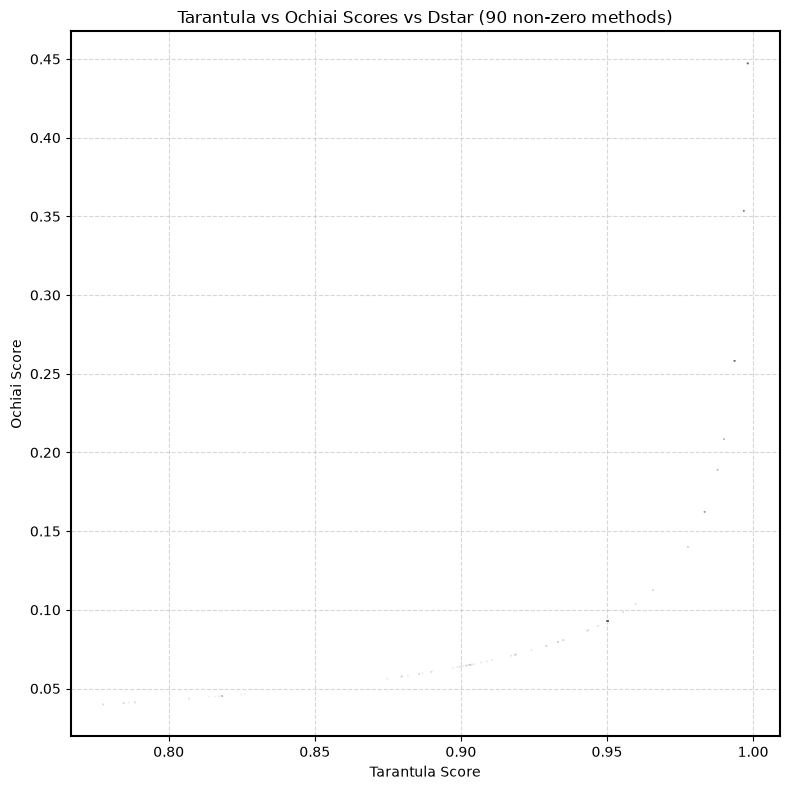

In [38]:
import matplotlib.pyplot as plt

# 1. Filter out methods where BOTH scores are exactly 0
# This keeps rows where either Tarantula > 0 OR Ochiai > 0
filtered_metrics = sbfl_metrics[(sbfl_metrics['tarantula'] > 0) | (sbfl_metrics['ochiai'] > 0) | (sbfl_metrics['dstar'] > 0)]

# 2. Create the plot setup
plt.figure(figsize=(8, 8))
ax = plt.gca()

# 3. Plot the scatter comparison
plt.scatter(
    filtered_metrics['tarantula'], 
    filtered_metrics['ochiai'], 
    filtered_metrics['dstar'], 
    alpha=0.7, 
    edgecolor='black' # Crisp border on the dots
)

# 4. Add the thick black border around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# 5. Standard Defaults
plt.title(f'Tarantula vs Ochiai Scores vs Dstar ({len(filtered_metrics)} non-zero methods)')
plt.xlabel('Tarantula Score')
plt.ylabel('Ochiai Score')
plt.grid(linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

Spearman Rank Correlation: 1.000


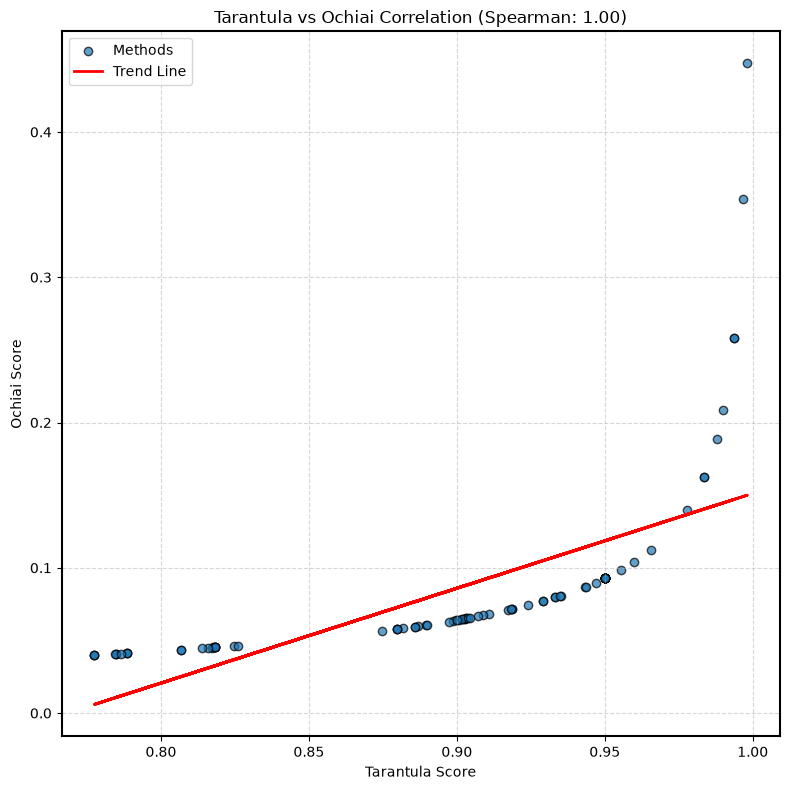

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter out the double-zeros again so they don't artificially inflate the correlation
filtered_metrics = sbfl_metrics[(sbfl_metrics['tarantula'] > 0) | (sbfl_metrics['ochiai'] > 0)]

x = filtered_metrics['tarantula']
y = filtered_metrics['ochiai']

# 2. Calculate the Spearman Rank Correlation using pandas
# 1.0 means perfect agreement in rankings, 0.0 means completely random
correlation = x.corr(y, method='spearman')
print(f"Spearman Rank Correlation: {correlation:.3f}")

# 3. Create the plot setup
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Plot the scatter points
plt.scatter(x, y, alpha=0.7, edgecolor='black', label='Methods')

# 4. Calculate and plot the Line of Best Fit (Trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, linestyle='-', label='Trend Line')

# 5. Add the thick black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# 6. Standard Formatting
plt.title(f'Tarantula vs Ochiai Correlation (Spearman: {correlation:.2f})')
plt.xlabel('Tarantula Score')
plt.ylabel('Ochiai Score')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Spearman Rank Correlation: 1.000


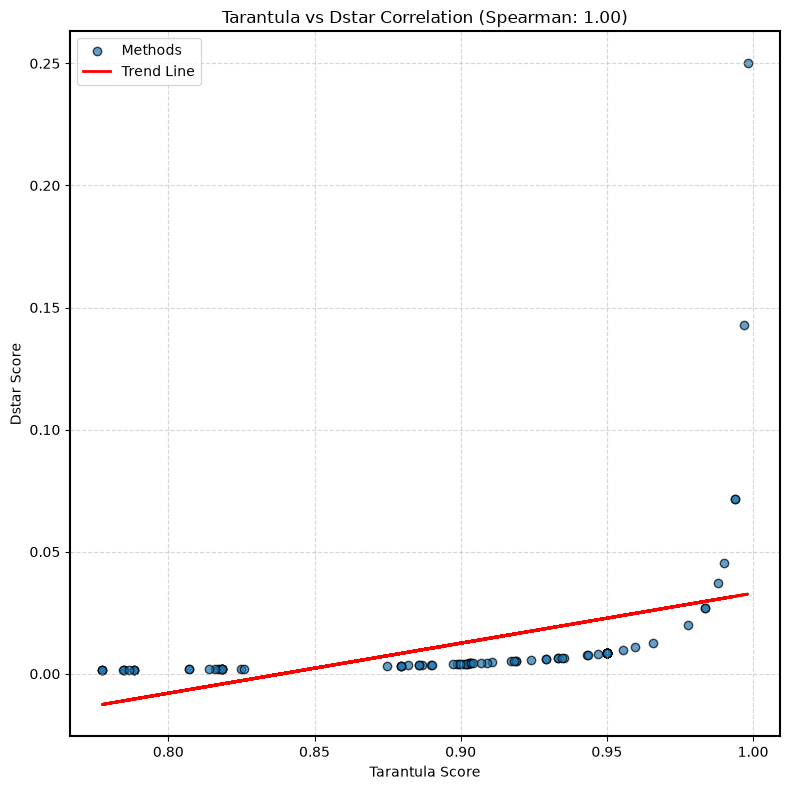

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter out the double-zeros again so they don't artificially inflate the correlation
filtered_metrics = sbfl_metrics[(sbfl_metrics['tarantula'] > 0) | (sbfl_metrics['ochiai'] > 0)]

x = filtered_metrics['tarantula']
y = filtered_metrics['dstar']

# 2. Calculate the Spearman Rank Correlation using pandas
# 1.0 means perfect agreement in rankings, 0.0 means completely random
correlation = x.corr(y, method='spearman')
print(f"Spearman Rank Correlation: {correlation:.3f}")

# 3. Create the plot setup
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Plot the scatter points
plt.scatter(x, y, alpha=0.7, edgecolor='black', label='Methods')

# 4. Calculate and plot the Line of Best Fit (Trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, linestyle='-', label='Trend Line')

# 5. Add the thick black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# 6. Standard Formatting
plt.title(f'Tarantula vs Dstar Correlation (Spearman: {correlation:.2f})')
plt.xlabel('Tarantula Score')
plt.ylabel('Dstar Score')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Applying Boykov Jolly and min marginals

In [41]:
cut_algo = BoykovJollyCut(G, tarantula, lambd=1)
cut_algo

In [42]:
cut_scores = []
for node in cut_algo.nodes:
    e0, e1 = cut_algo.compute_min_marginals(node)
    confidence = e0 - e1 # Higher is more buggy
    cut_scores.append({"Method": node, "GraphCut_Score": confidence})

In [43]:
cut_df = pd.DataFrame(cut_scores)
cut_df.sort_values(by="GraphCut_Score", ascending=False)

,Method,GraphCut_Score
31,org.jfree.chart.util.AbstractObjectList#Abstra...,2.028856e+01
17,org.jfree.chart.renderer.AbstractRenderer#Abst...,1.710713e+01
78,org.jfree.chart.plot.CategoryPlot#CategoryPlot...,1.343537e+01
58,org.jfree.chart.plot.CategoryPlot#datasetChang...,1.163755e+01
27,org.jfree.chart.plot.CategoryPlot#setRenderer(...,1.083657e+01
...,...,...
12,org.jfree.chart.util.AbstractObjectList#equals...,-1.000000e+09
15,org.jfree.chart.renderer.category.AbstractCate...,-1.000000e+09
13,org.jfree.chart.renderer.category.AbstractCate...,-1.000000e+09
14,org.jfree.chart.event.RendererChangeEvent#Rend...,-1.000000e+09


In [44]:
sbfl_metrics = sbfl_metrics.reset_index().rename(columns={'index': 'Method'})
sbfl_metrics

,Method,tarantula,ochiai,dstar
0,org.jfree.chart.renderer.AbstractRenderer#Abst...,0.818351,0.045268,0.002053
1,org.jfree.chart.renderer.AbstractRenderer#isSe...,0.000000,0.000000,0.000000
2,org.jfree.chart.renderer.AbstractRenderer#setB...,0.000000,0.000000,0.000000
3,org.jfree.chart.renderer.AbstractRenderer#getD...,0.000000,0.000000,0.000000
4,org.jfree.chart.renderer.AbstractRenderer#addC...,0.917224,0.070888,0.005051
...,...,...,...,...
193,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000
194,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000
195,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000
196,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000


In [45]:
merged_results = pd.merge(sbfl_metrics, cut_df, on="Method", how="left")

In [46]:
merged_results

,Method,tarantula,ochiai,dstar,GraphCut_Score
0,org.jfree.chart.renderer.AbstractRenderer#Abst...,0.818351,0.045268,0.002053,1.710713e+01
1,org.jfree.chart.renderer.AbstractRenderer#isSe...,0.000000,0.000000,0.000000,-1.000000e+09
2,org.jfree.chart.renderer.AbstractRenderer#setB...,0.000000,0.000000,0.000000,-1.000000e+09
3,org.jfree.chart.renderer.AbstractRenderer#getD...,0.000000,0.000000,0.000000,-1.000000e+09
4,org.jfree.chart.renderer.AbstractRenderer#addC...,0.917224,0.070888,0.005051,3.098362e+00
...,...,...,...,...,...
193,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09
194,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09
195,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09
196,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09


In [47]:
actual_buggy_node = 'org.jfree.chart.renderer.category.AbstractCategoryItemRenderer#getLegendItems()'

In [48]:
# instance = bugs[0]
# project, bug_id = str(instance).split("/")[-1].split("_")
# project, bug_id

In [49]:
# get_buggy_nodes("Chart", 2)[0]



In [50]:
# 1. Define the columns you want to rank
metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']

# 2. Loop through and create a new rank column for each
for metric in metrics:
    merged_results[f'{metric}_rank'] = merged_results[metric].rank(ascending=False, method='min')

# 3. (Optional) Sort the table by one of the ranks to see the top suspicious methods
merged_results = merged_results.sort_values(by='tarantula_rank')

# Display the updated dataframe
merged_results

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank
150,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.998180,0.447214,0.250000,7.000334e+00,1.0,1.0,1.0,17.0
151,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.996820,0.353553,0.142857,1.083657e+01,2.0,2.0,2.0,5.0
133,org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429,5.747571e+00,3.0,3.0,3.0,25.0
143,org.jfree.chart.plot.CategoryPlot#setDataset(o...,0.993659,0.258199,0.071429,5.747571e+00,3.0,3.0,3.0,25.0
144,org.jfree.chart.plot.CategoryPlot#setDataset(i...,0.990072,0.208514,0.045455,8.305146e+00,5.0,5.0,5.0,10.0
...,...,...,...,...,...,...,...,...,...
76,org.jfree.chart.util.StandardGradientPaintTran...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,109.0
77,org.jfree.chart.util.GradientPaintTransformTyp...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,156.0
81,org.jfree.chart.event.RendererChangeEvent#Rend...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,188.0
66,org.jfree.chart.text.TextAnchor#equals(java.la...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,109.0


In [51]:
merged_results.columns

Index(['Method', 'tarantula', 'ochiai', 'dstar', 'GraphCut_Score',
       'tarantula_rank', 'ochiai_rank', 'dstar_rank', 'GraphCut_Score_rank'],
      dtype='object')

In [52]:
total_methods = len(merged_results)

# 2. Define the metrics
metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']

# 3. Loop through and compute Expected Rank and EXAM Score
for metric in metrics:
    # Use method='average' to calculate the mathematically expected number of inspections for ties
    expected_rank = merged_results[metric].rank(ascending=False, method='average')
    
    # Store the raw number of average inspections (Optional, but helpful for human reading)
    merged_results[f'{metric}_expected_inspections'] = expected_rank
    
    # Calculate the EXAM Score (Fraction of codebase inspected)
    merged_results[f'{metric}_exam_score'] = expected_rank / total_methods

# 4. Sort the table by one of the EXAM scores to see the best results at the top
merged_results = merged_results.sort_values(by='tarantula_exam_score')

# Display the updated dataframe
merged_results

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank,tarantula_expected_inspections,tarantula_exam_score,ochiai_expected_inspections,ochiai_exam_score,dstar_expected_inspections,dstar_exam_score,GraphCut_Score_expected_inspections,GraphCut_Score_exam_score
150,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.998180,0.447214,0.250000,7.000334e+00,1.0,1.0,1.0,17.0,1.0,0.005051,1.0,0.005051,1.0,0.005051,17.0,0.085859
151,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.996820,0.353553,0.142857,1.083657e+01,2.0,2.0,2.0,5.0,2.0,0.010101,2.0,0.010101,2.0,0.010101,5.0,0.025253
133,org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429,5.747571e+00,3.0,3.0,3.0,25.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,25.5,0.128788
143,org.jfree.chart.plot.CategoryPlot#setDataset(o...,0.993659,0.258199,0.071429,5.747571e+00,3.0,3.0,3.0,25.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,25.5,0.128788
144,org.jfree.chart.plot.CategoryPlot#setDataset(i...,0.990072,0.208514,0.045455,8.305146e+00,5.0,5.0,5.0,10.0,5.0,0.025253,5.0,0.025253,5.0,0.025253,10.0,0.050505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,org.jfree.chart.annotations.TextAnnotation#get...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,109.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,132.0,0.666667
191,org.jfree.chart.annotations.TextAnnotation#equ...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,169.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,173.0,0.873737
182,org.jfree.chart.labels.StandardCategoryItemLab...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,109.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,132.0,0.666667
30,org.jfree.chart.renderer.category.AbstractCate...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,109.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,132.0,0.666667


In [53]:
[val for val in merged_results.Method.values if val.startswith(actual_buggy_node)]

['org.jfree.chart.renderer.category.AbstractCategoryItemRenderer#getLegendItems()']

In [54]:
merged_results[merged_results['Method'] == actual_buggy_node]

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank,tarantula_expected_inspections,tarantula_exam_score,ochiai_expected_inspections,ochiai_exam_score,dstar_expected_inspections,dstar_exam_score,GraphCut_Score_expected_inspections,GraphCut_Score_exam_score
33,org.jfree.chart.renderer.category.AbstractCate...,0.983416,0.162221,0.027027,7.889226,7.0,7.0,7.0,13.0,7.5,0.037879,7.5,0.037879,7.5,0.037879,13.0,0.065657


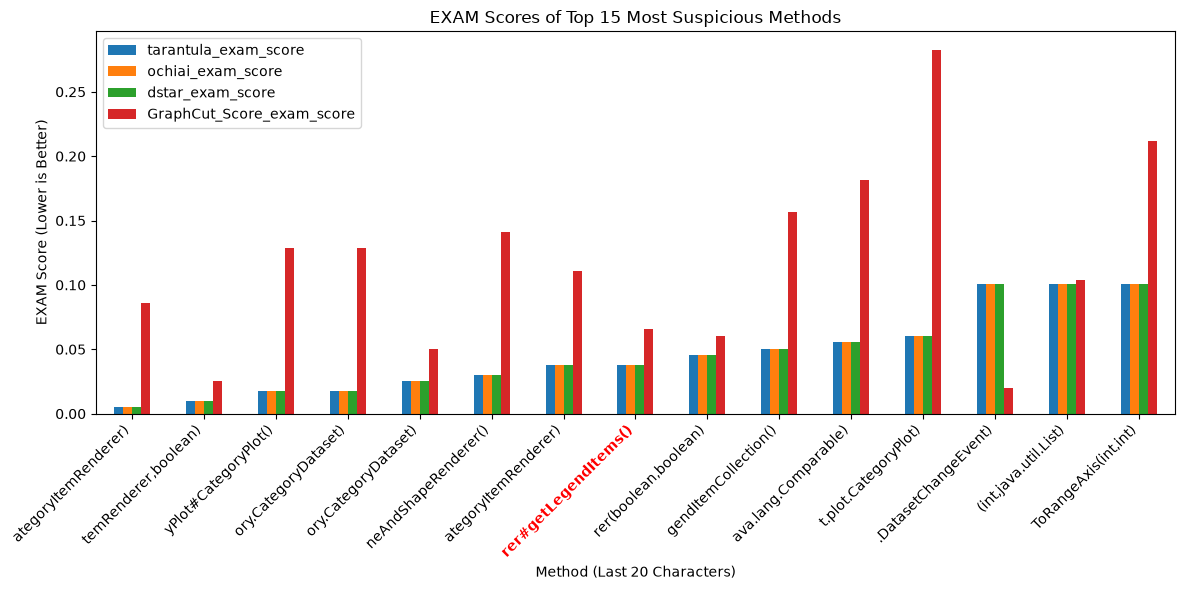

In [55]:
import matplotlib.pyplot as plt
k = 15
# 1. Setup the Top 10 dataframe exactly as before
top_k = merged_results.sort_values(by='tarantula_exam_score').head(k).copy()
top_k['Short_Method'] = top_k['Method'].str[-20:]
top_k.set_index('Short_Method', inplace=True)

exam_cols = ['tarantula_exam_score', 'ochiai_exam_score', 'dstar_exam_score', 'GraphCut_Score_exam_score']

# 2. Create the default plot and save it to 'ax'
ax = top_k[exam_cols].plot(kind='bar', figsize=(12, 6))

# 3. Add standard labels
plt.title(f'EXAM Scores of Top {k} Most Suspicious Methods')
plt.xlabel('Method (Last 20 Characters)')
plt.ylabel('EXAM Score (Lower is Better)')
plt.xticks(rotation=45, ha='right')

short_buggy_node = actual_buggy_node[-20:]

# Loop through the labels and turn the buggy one red and bold
for label in ax.get_xticklabels():
    if label.get_text() == short_buggy_node:
        label.set_color('red')
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [56]:
def normalize_scores(scores: dict) -> dict:
    finite = [v for v in scores.values() if math.isfinite(v)]
    if not finite:
        return {k: 0.0 for k in scores}
    lo, hi = min(finite), max(finite)
    if hi == lo:
        return {k: 0.5 for k in scores}
    out = {}
    for k, v in scores.items():
        out[k] = 1.0 if not math.isfinite(v) else (v - lo) / (hi - lo)
    return out

def compute_graphcut_scores(G: nx.DiGraph, node_scores: dict, lambd: float) -> dict:
    cut_algo = BoykovJollyCut(G, normalize_scores(node_scores), lambd=lambd)
    return {node: (lambda em: em[0] - em[1])(cut_algo.compute_min_marginals(node))
            for node in cut_algo.nodes}

def evaluate(project, bug_id, lambd=1.0):
    extraction_res = load_pregen_data(project, bug_id)

    G = json_to_digraph(extraction_res.graph_json)
    nodes = list(G.nodes())

    graph_nodes_no_args = {n.split('(')[0] for n in nodes}
    for buggy_method in extraction_res.buggy_methods:
        bm = buggy_method.replace('$', '.').split('(')[0]
        if bm not in graph_nodes_no_args:
            logging.warning(
                f"[{project}:{bug_id}] buggy method {buggy_method} not in call graph "
                f"(ground truth only; rankings still exported)"
            )

    data_dir = ROOT_DIR / "data" / "defects4j" / f"{project}_{bug_id}"
    coverage_df = pd.read_csv(data_dir / "coverage.csv")

    baselines = {
        "tarantula": compute_method_tarantula(coverage_df),
        "ochiai": compute_method_ochiai(coverage_df),
        "dstar": compute_method_dstar(coverage_df),
    }

    nodes_coverage = set(baselines["tarantula"].keys())
    missing_in_cov = set(nodes) - nodes_coverage
    if missing_in_cov:
        logging.warning(
            f"[{project}:{bug_id}] {len(missing_in_cov)} graph nodes missing from "
            f"coverage (assigned score 0.0)"
        )

    # Project each baseline onto the graph nodes (uncovered nodes -> 0.0).
    metric_on_nodes = {
        name: {node: scores.get(node, 0.0) for node in nodes}
        for name, scores in baselines.items()
    }

    results = pd.DataFrame(metric_on_nodes)

    for name, node_scores in metric_on_nodes.items():
        gc_scores = compute_graphcut_scores(G, node_scores, lambd)
        results[f"{name}_gc"] = results.index.map(gc_scores)

    results = results.reset_index().rename(columns={"index": "Method"})

    # Ranks + EXAM (expected inspection cost) for every baseline and its GC pair.
    score_cols = ["tarantula", "tarantula_gc",
                  "ochiai", "ochiai_gc",
                  "dstar", "dstar_gc"]
    total_methods = len(results)
    for col in score_cols:
        results[f"{col}_rank"] = results[col].rank(ascending=False, method="min")
        expected_rank = results[col].rank(ascending=False, method="average")
        results[f"{col}_expected_inspections"] = expected_rank
        results[f"{col}_exam_score"] = expected_rank / total_methods

    return results.sort_values(by="tarantula_rank")

In [57]:
res_jsoup_1 = evaluate("Jsoup", 1, 1.0)
res_jsoup_1

,Method,tarantula,ochiai,dstar,tarantula_gc,ochiai_gc,dstar_gc,tarantula_rank,tarantula_expected_inspections,tarantula_exam_score,...,ochiai_exam_score,ochiai_gc_rank,ochiai_gc_expected_inspections,ochiai_gc_exam_score,dstar_rank,dstar_expected_inspections,dstar_exam_score,dstar_gc_rank,dstar_gc_expected_inspections,dstar_gc_exam_score
12,org.jsoup.nodes.Node#removeChild(org.jsoup.nod...,0.964539,0.408248,0.200000,2.624475e+01,2.624475e+01,2.624475e+01,1.0,1.0,0.006135,...,0.006135,1.0,1.0,0.006135,1.0,1.0,0.006135,1.0,1.0,0.006135
103,org.jsoup.nodes.TextNode#stripLeadingWhitespac...,0.944444,0.333333,0.125000,2.240710e+00,-1.166485e-01,-1.098612e+00,2.0,2.0,0.012270,...,0.012270,2.0,2.0,0.012270,2.0,2.0,0.012270,2.0,2.0,0.012270
49,org.jsoup.nodes.Node#indexInList(org.jsoup.nod...,0.786127,0.162221,0.027027,-6.482522e+00,-8.382024e+00,-9.821844e+00,3.0,3.0,0.018405,...,0.018405,24.0,24.0,0.147239,3.0,3.0,0.018405,23.0,23.0,0.141104
37,org.jsoup.nodes.TextNode#lastCharIsWhitespace(...,0.777143,0.158114,0.025641,-1.573333e+00,-3.454415e+00,-4.912655e+00,4.0,4.0,0.024540,...,0.024540,8.0,8.0,0.049080,4.0,4.0,0.024540,8.0,8.0,0.049080
73,org.jsoup.nodes.TextNode#isBlank(),0.772727,0.156174,0.025000,-5.404529e+00,-7.276696e+00,-8.743851e+00,5.0,5.0,0.030675,...,0.030675,19.0,19.0,0.116564,5.0,5.0,0.030675,18.0,18.0,0.110429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,org.jsoup.nodes.DataNode#DataNode(java.lang.St...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,126.0,129.5,0.794479,104.0,133.5,0.819018,119.0,131.5,0.806748
58,org.jsoup.nodes.Element#appendElement(java.lan...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,110.0,110.0,0.674847,104.0,133.5,0.819018,108.0,113.0,0.693252
130,org.jsoup.nodes.Evaluator.Id#matches(org.jsoup...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,134.0,144.5,0.886503,104.0,133.5,0.819018,119.0,131.5,0.806748
96,org.jsoup.nodes.Attribute#createFromEncoded(ja...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,134.0,144.5,0.886503,104.0,133.5,0.819018,119.0,131.5,0.806748


In [58]:
res_jsoup_1.sort_values(by="tarantula_gc_rank")

,Method,tarantula,ochiai,dstar,tarantula_gc,ochiai_gc,dstar_gc,tarantula_rank,tarantula_expected_inspections,tarantula_exam_score,...,ochiai_exam_score,ochiai_gc_rank,ochiai_gc_expected_inspections,ochiai_gc_exam_score,dstar_rank,dstar_expected_inspections,dstar_exam_score,dstar_gc_rank,dstar_gc_expected_inspections,dstar_gc_exam_score
12,org.jsoup.nodes.Node#removeChild(org.jsoup.nod...,0.964539,0.408248,0.200000,2.624475e+01,2.624475e+01,2.624475e+01,1.0,1.0,0.006135,...,0.006135,1.0,1.0,0.006135,1.0,1.0,0.006135,1.0,1.0,0.006135
103,org.jsoup.nodes.TextNode#stripLeadingWhitespac...,0.944444,0.333333,0.125000,2.240710e+00,-1.166485e-01,-1.098612e+00,2.0,2.0,0.012270,...,0.012270,2.0,2.0,0.012270,2.0,2.0,0.012270,2.0,2.0,0.012270
161,org.jsoup.parser.Tag#setEmpty(),0.501845,0.085749,0.007407,8.122544e-02,-1.324672e+00,-3.258097e+00,93.0,98.0,0.601227,...,0.601227,3.0,5.0,0.030675,93.0,98.0,0.601227,3.0,4.0,0.024540
162,org.jsoup.parser.Tag#setContainDataOnly(),0.501845,0.085749,0.007407,8.122544e-02,-1.324672e+00,-3.258097e+00,93.0,98.0,0.601227,...,0.601227,3.0,5.0,0.030675,93.0,98.0,0.601227,3.0,4.0,0.024540
158,org.jsoup.parser.Tag#setOptionalClosing(),0.501845,0.085749,0.007407,8.122544e-02,-1.324672e+00,-3.258097e+00,93.0,98.0,0.601227,...,0.601227,3.0,5.0,0.030675,93.0,98.0,0.601227,7.0,7.0,0.042945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,org.jsoup.select.Selector#filterForDescendants...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,111.0,114.0,0.699387,104.0,133.5,0.819018,108.0,113.0,0.693252
18,org.jsoup.nodes.Document#title(),0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,108.0,108.0,0.662577,104.0,133.5,0.819018,104.0,105.5,0.647239
2,org.jsoup.nodes.DataNode#outerHtml(java.lang.S...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,105.0,106.0,0.650307,104.0,133.5,0.819018,108.0,113.0,0.693252
4,org.jsoup.nodes.Element#html(java.lang.StringB...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,105.0,106.0,0.650307,104.0,133.5,0.819018,108.0,113.0,0.693252


In [59]:
res_jsoup_1_1 = evaluate("Jsoup", 1, 1.0)
res_jsoup_1_1.sort_values(by="tarantula_gc_rank").Method.values[:5]

array(['org.jsoup.nodes.Node#removeChild(org.jsoup.nodes.Node)',
       'org.jsoup.nodes.TextNode#stripLeadingWhitespace(java.lang.String)',
       'org.jsoup.parser.Tag#setEmpty()',
       'org.jsoup.parser.Tag#setContainDataOnly()',
       'org.jsoup.parser.Tag#setOptionalClosing()'], dtype=object)

In [60]:
res_jsoup_1.sort_values(by="tarantula_gc_rank")

,Method,tarantula,ochiai,dstar,tarantula_gc,ochiai_gc,dstar_gc,tarantula_rank,tarantula_expected_inspections,tarantula_exam_score,...,ochiai_exam_score,ochiai_gc_rank,ochiai_gc_expected_inspections,ochiai_gc_exam_score,dstar_rank,dstar_expected_inspections,dstar_exam_score,dstar_gc_rank,dstar_gc_expected_inspections,dstar_gc_exam_score
12,org.jsoup.nodes.Node#removeChild(org.jsoup.nod...,0.964539,0.408248,0.200000,2.624475e+01,2.624475e+01,2.624475e+01,1.0,1.0,0.006135,...,0.006135,1.0,1.0,0.006135,1.0,1.0,0.006135,1.0,1.0,0.006135
103,org.jsoup.nodes.TextNode#stripLeadingWhitespac...,0.944444,0.333333,0.125000,2.240710e+00,-1.166485e-01,-1.098612e+00,2.0,2.0,0.012270,...,0.012270,2.0,2.0,0.012270,2.0,2.0,0.012270,2.0,2.0,0.012270
161,org.jsoup.parser.Tag#setEmpty(),0.501845,0.085749,0.007407,8.122544e-02,-1.324672e+00,-3.258097e+00,93.0,98.0,0.601227,...,0.601227,3.0,5.0,0.030675,93.0,98.0,0.601227,3.0,4.0,0.024540
162,org.jsoup.parser.Tag#setContainDataOnly(),0.501845,0.085749,0.007407,8.122544e-02,-1.324672e+00,-3.258097e+00,93.0,98.0,0.601227,...,0.601227,3.0,5.0,0.030675,93.0,98.0,0.601227,3.0,4.0,0.024540
158,org.jsoup.parser.Tag#setOptionalClosing(),0.501845,0.085749,0.007407,8.122544e-02,-1.324672e+00,-3.258097e+00,93.0,98.0,0.601227,...,0.601227,3.0,5.0,0.030675,93.0,98.0,0.601227,7.0,7.0,0.042945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21,org.jsoup.select.Selector#filterForDescendants...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,111.0,114.0,0.699387,104.0,133.5,0.819018,108.0,113.0,0.693252
18,org.jsoup.nodes.Document#title(),0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,108.0,108.0,0.662577,104.0,133.5,0.819018,104.0,105.5,0.647239
2,org.jsoup.nodes.DataNode#outerHtml(java.lang.S...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,105.0,106.0,0.650307,104.0,133.5,0.819018,108.0,113.0,0.693252
4,org.jsoup.nodes.Element#html(java.lang.StringB...,0.000000,0.000000,0.000000,-1.000000e+09,-1.000000e+09,-1.000000e+09,104.0,133.5,0.819018,...,0.819018,105.0,106.0,0.650307,104.0,133.5,0.819018,108.0,113.0,0.693252


In [61]:
res_jsoup_1.columns

Index(['Method', 'tarantula', 'ochiai', 'dstar', 'tarantula_gc', 'ochiai_gc',
       'dstar_gc', 'tarantula_rank', 'tarantula_expected_inspections',
       'tarantula_exam_score', 'tarantula_gc_rank',
       'tarantula_gc_expected_inspections', 'tarantula_gc_exam_score',
       'ochiai_rank', 'ochiai_expected_inspections', 'ochiai_exam_score',
       'ochiai_gc_rank', 'ochiai_gc_expected_inspections',
       'ochiai_gc_exam_score', 'dstar_rank', 'dstar_expected_inspections',
       'dstar_exam_score', 'dstar_gc_rank', 'dstar_gc_expected_inspections',
       'dstar_gc_exam_score'],
      dtype='object')

In [62]:
res_jsoup_0_1 = evaluate("Jsoup", 1, 0.001)
res_jsoup_0_1.sort_values(by="tarantula_gc_rank").Method.values[:5]

array(['org.jsoup.nodes.Node#removeChild(org.jsoup.nodes.Node)',
       'org.jsoup.nodes.TextNode#stripLeadingWhitespace(java.lang.String)',
       'org.jsoup.nodes.Node#indexInList(org.jsoup.nodes.Node,java.util.List)',
       'org.jsoup.nodes.TextNode#lastCharIsWhitespace(java.lang.StringBuilder)',
       'org.jsoup.nodes.TextNode#isBlank()'], dtype=object)

In [63]:
actual_buggy_node = get_buggy_nodes("Jsoup", 1)[0]
actual_buggy_node

/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_14539/3337755200.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  buggy_nodes = df_gt[df_gt['project']==proj][df_gt['bug_id'] == bugid].buggy_nodes.values[0]


'org.jsoup.nodes.Document#normalise(org.jsoup.nodes.Element)'

In [64]:

fig, axes = plot_topk_comparison(
    df=res_jsoup_1,
    buggy_nodes=actual_buggy_node,
    k=10
)

plt.show()

NameError: name 'plot_topk_comparison' is not defined

In [ ]:
# Full Benchmark
single_bug_instances

In [ ]:
# import os
# import pandas as pd
# from tqdm import tqdm

# # 1. Setup
# output_dir = "eval_results"
# os.makedirs(output_dir, exist_ok=True)
# lambd_value = 1.0
# failed_runs = []

# # 2. Get a list of all unique projects (e.g., 'Chart', 'Time', 'Math')
# projects = single_bug_instances['project'].unique()

# print(f"Starting staged benchmark across {len(projects)} projects...\n")

# # 3. The Outer Loop (By Project)
# for project in projects:
#     # Isolate just the bugs for this specific project
#     project_df = single_bug_instances[single_bug_instances['project'] == project]
#     print(f"Processing Project: {project} ({len(project_df)} bugs) ")
    
#     # 4. The Inner Loop (By Bug ID)
#     # This creates a fresh, clean progress bar for every project
#     for index, row in tqdm(project_df.iterrows(), total=len(project_df), desc=f"{project} Progress"):
#         bug_id = row['bug_id']
#         filepath = os.path.join(output_dir, f"{project}_{bug_id}_{lambd_value}.csv")
        
#         if os.path.exists(filepath):
#             continue
            
#         try:
#             # Run the heavy evaluation
#             result_df = evaluate(project, bug_id, lambd=lambd_value)
            
#             # Save the results
#             result_df.to_csv(filepath, index=False)
            
#         except Exception as e:
#             failed_runs.append({'project': project, 'bug_id': bug_id, 'error': str(e)})
            
#     print("") # Adds a blank line between projects for readability

# # 5. Final Summary
# print(f"All Projects Complete")
# if failed_runs:
#     print(f"Encountered {len(failed_runs)} failed instances. Check the 'failed_runs' list for details.")

In [ ]:
# GRound truths
df_gt= pd.read_csv("/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/ground_truth.csv")
df_gt

In [ ]:
import ast
filtered_df = df_gt[df_gt['buggy_methods'].apply(lambda x: len(ast.literal_eval(x)) > 1)]

# Display the result
filtered_df

In [ ]:
# Eval results

In [ ]:
eval_dir = "/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/evals_lambd1/eval_lambd_1.0"
files = [file.name for file in Path(eval_dir).iterdir() if file.is_file()]
files

In [ ]:
ast.literal_eval(df_gt.buggy_nodes[0])[0], type(df_gt.buggy_nodes[0])

In [ ]:
# Comparison

results = {}
for csv_file in files:
    proj, bugid = csv_file.split("_")[0], int(csv_file.split("_")[1])
    buggy_nodes = df_gt[df_gt['project']==proj][df_gt['bug_id'] == bugid].buggy_nodes.values[0]
    buggy_nodes_list = ast.literal_eval(buggy_nodes)
    d = {
        "project": proj,
        "bug_id": bugid,
        "buggy_nodes": buggy_nodes_list,
        "results": pd.read_csv(f"{eval_dir}/{proj}_{bugid}_1.0.csv")
    }
    results[csv_file] = d

In [ ]:
results['Math_70_1.0.csv']['results'].columns

In [ ]:
import pandas as pd
import numpy as np
import re

# -----------------------------
# Configuration
# -----------------------------

APPROACHES = [
    "tarantula",
    "tarantula_gc",
    "ochiai",
    "ochiai_gc",
    "dstar",
    "dstar_gc",
]

PAIRS = [
    ("tarantula", "tarantula_gc"),
    ("ochiai", "ochiai_gc"),
    ("dstar", "dstar_gc"),
]

TOPKS = [1, 3, 5, 10]


# -----------------------------
# Matching helpers
# -----------------------------

def match_buggy_rows(df, buggy_nodes, match_mode="exact"):
    """
    Returns rows in df whose Method matches one of the ground-truth buggy nodes.

    match_mode:
      - "exact": Method must exactly equal buggy node string
      - "contains": Method contains buggy node string or vice versa
    """
    df = df.copy()
    df["Method"] = df["Method"].astype(str)

    buggy_nodes = [str(x) for x in buggy_nodes]

    if match_mode == "exact":
        matched = df[df["Method"].isin(buggy_nodes)].copy()
        return matched

    elif match_mode == "contains":
        masks = []
        for node in buggy_nodes:
            escaped = re.escape(node)
            mask = (
                df["Method"].str.contains(escaped, regex=True, na=False)
                | pd.Series([node in m for m in df["Method"]], index=df.index)
            )
            masks.append(mask)

        if not masks:
            return df.iloc[0:0].copy()

        combined = masks[0]
        for mask in masks[1:]:
            combined = combined | mask

        return df[combined].copy()

    else:
        raise ValueError("match_mode must be either 'exact' or 'contains'")


def get_best_buggy_node_stats(rows, approach):
    """
    For one bug and one approach, select the buggy node with the best rank.

    Lower rank is better.
    Lower EXAM score is better.
    """
    rank_col = f"{approach}_rank"
    exam_col = f"{approach}_exam_score"
    inspections_col = f"{approach}_expected_inspections"
    score_col = approach

    if rows.empty or rank_col not in rows.columns:
        return {
            f"{approach}_best_buggy_node": np.nan,
            f"{approach}_rank": np.nan,
            f"{approach}_exam_score": np.nan,
            f"{approach}_expected_inspections": np.nan,
            f"{approach}_score": np.nan,
        }

    tmp = rows.copy()
    tmp[rank_col] = pd.to_numeric(tmp[rank_col], errors="coerce")

    valid = tmp.dropna(subset=[rank_col])

    if valid.empty:
        return {
            f"{approach}_best_buggy_node": np.nan,
            f"{approach}_rank": np.nan,
            f"{approach}_exam_score": np.nan,
            f"{approach}_expected_inspections": np.nan,
            f"{approach}_score": np.nan,
        }

    best_idx = valid[rank_col].idxmin()
    best = valid.loc[best_idx]

    return {
        f"{approach}_best_buggy_node": best["Method"],
        f"{approach}_rank": best.get(rank_col, np.nan),
        f"{approach}_exam_score": best.get(exam_col, np.nan),
        f"{approach}_expected_inspections": best.get(inspections_col, np.nan),
        f"{approach}_score": best.get(score_col, np.nan),
    }


# -----------------------------
# Build results_df
# -----------------------------

def build_results_df(results, approaches=APPROACHES, topks=TOPKS, match_mode="exact"):
    records = []

    for csv_file, item in results.items():
        project = item["project"]
        bug_id = item["bug_id"]
        buggy_nodes = item["buggy_nodes"]
        df = item["results"].copy()

        buggy_rows = match_buggy_rows(df, buggy_nodes, match_mode=match_mode)

        record = {
            "csv_file": csv_file,
            "project": project,
            "bug_id": bug_id,
            "bug_key": f"{project}_{bug_id}",
            "buggy_nodes": buggy_nodes,
            "n_buggy_nodes": len(buggy_nodes),
            "n_matched_buggy_nodes": len(buggy_rows),
            "matched_buggy_nodes": sorted(buggy_rows["Method"].astype(str).unique().tolist())
                if not buggy_rows.empty else [],
        }

        for approach in approaches:
            stats = get_best_buggy_node_stats(buggy_rows, approach)
            record.update(stats)

            rank = stats[f"{approach}_rank"]
            for k in topks:
                record[f"{approach}_top{k}"] = (
                    bool(pd.notna(rank) and rank <= k)
                )

        records.append(record)

    results_df = pd.DataFrame(records)

    # Convert numeric metric columns
    for approach in approaches:
        for suffix in ["rank", "exam_score", "expected_inspections", "score"]:
            col = f"{approach}_{suffix}"
            if col in results_df.columns:
                results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

    return results_df


results_df = build_results_df(
    results,
    approaches=APPROACHES,
    topks=TOPKS,
    match_mode="exact",   # change to "contains" if Method names do not exactly match buggy_nodes
)

results_df.head()

In [ ]:
results_df

In [ ]:
def summarize_pairs(results_df, pairs=PAIRS, topks=TOPKS):
    rows = []

    for base, gc in pairs:
        valid = results_df[
            results_df[f"{base}_rank"].notna()
            & results_df[f"{gc}_rank"].notna()
        ].copy()

        row = {
            "comparison": f"{gc} vs {base}",
            "base": base,
            "gc": gc,
            "n_valid_bugs": len(valid),

            "gc_better_rank_count": (valid[f"{gc}_rank"] < valid[f"{base}_rank"]).sum(),
            "base_better_rank_count": (valid[f"{gc}_rank"] > valid[f"{base}_rank"]).sum(),
            "tie_rank_count": (valid[f"{gc}_rank"] == valid[f"{base}_rank"]).sum(),

            "mean_rank_improvement": (
                valid[f"{base}_rank"] - valid[f"{gc}_rank"]
            ).mean(),

            "median_rank_improvement": (
                valid[f"{base}_rank"] - valid[f"{gc}_rank"]
            ).median(),

            "mean_exam_improvement": (
                valid[f"{base}_exam_score"] - valid[f"{gc}_exam_score"]
            ).mean(),

            "median_exam_improvement": (
                valid[f"{base}_exam_score"] - valid[f"{gc}_exam_score"]
            ).median(),
        }

        for k in topks:
            row[f"{base}_top{k}_rate"] = valid[f"{base}_top{k}"].mean()
            row[f"{gc}_top{k}_rate"] = valid[f"{gc}_top{k}"].mean()
            row[f"top{k}_rate_delta"] = (
                valid[f"{gc}_top{k}"].mean()
                - valid[f"{base}_top{k}"].mean()
            )

        rows.append(row)

    return pd.DataFrame(rows)


pairwise_df = summariz1e_pairs(results_df)

pairwise_df

# Compare graph generation overhead

In [65]:
extraction_csv = pd.read_csv("/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/extraction_benchmark.csv")
extraction_csv

,project,bug_id,status,checkout_compile_time_sec,list_tests_time_sec,collect_coverage_time_sec,export_csv_time_sec,call_graph_agent_time_sec,call_graph_parse_time_sec,total_pipeline_time_sec,total_tests,coverage_matrix_rows,coverage_matrix_cols,call_graph_nodes,call_graph_edges
0,JacksonCore,1,Success,4.113736,0.000047,0.000011,0.147638,0.000033,0.000751,6.679544,206,205,8376,212,301
1,JacksonCore,2,Success,2.639656,0.000045,0.000010,0.151652,0.000032,0.000440,5.212840,214,214,8476,142,150
2,JacksonCore,3,Success,4.034044,0.000046,0.000010,0.138319,0.000034,0.000314,6.560200,220,219,8599,94,88
3,JacksonCore,4,Success,3.053340,0.000062,0.000011,0.155044,0.000035,0.000131,5.609378,239,239,9038,20,16
4,JacksonCore,5,Success,0.000007,0.000047,7.744539,0.649480,3.032722,0.000152,13.858681,242,242,9048,9,10
5,JacksonDatabind,1,Success,6.433733,0.520191,80.872968,6.864581,3.883870,0.002345,101.059144,1119,1117,18721,652,1013
6,JacksonDatabind,2,Success,7.612934,0.435525,97.686829,8.925047,3.905162,0.003165,121.044193,1252,1250,20690,925,1467
7,JacksonDatabind,3,Success,7.851447,0.514432,97.344043,8.878307,4.359604,0.003930,121.399385,1255,1253,20731,1012,1792
8,JacksonDatabind,4,Success,7.237502,0.428474,100.587636,8.888573,3.885884,0.002637,123.498404,1260,1258,20750,762,1218
9,JacksonDatabind,5,Success,7.890385,0.429413,99.001324,8.873454,3.829729,0.001217,122.494663,1261,1259,20781,346,452


--- Benchmark Results ---
Average Call Graph Extraction Overhead: 12.01% of total pipeline time.



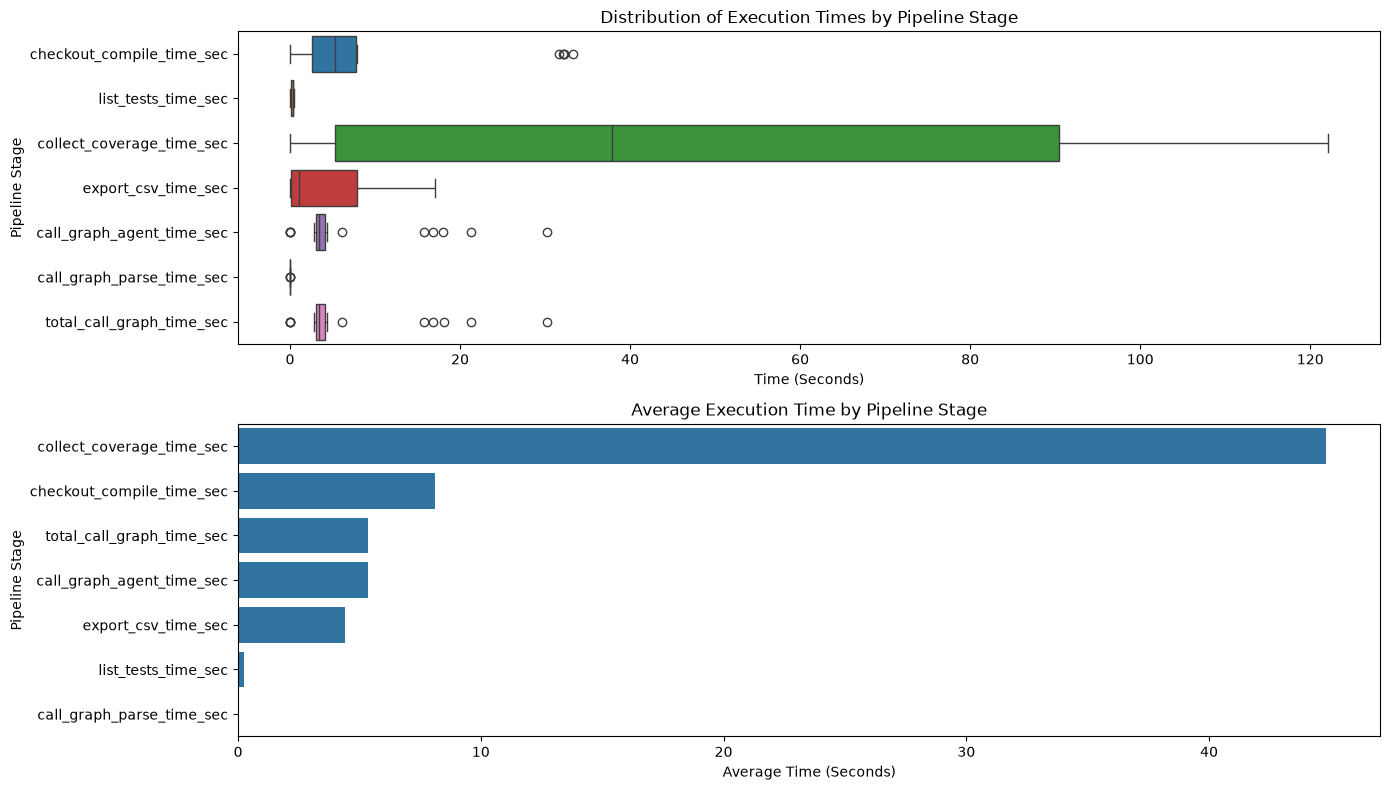

,mean,median,max,std
checkout_compile_time_sec,8.10,5.27,33.24,9.53
list_tests_time_sec,0.26,0.31,0.52,0.14
collect_coverage_time_sec,44.80,37.84,122.09,41.75
export_csv_time_sec,4.41,1.10,17.04,5.80
call_graph_agent_time_sec,5.34,3.41,30.25,6.21
call_graph_parse_time_sec,0.00,0.00,0.00,0.00
total_call_graph_time_sec,5.34,3.42,30.25,6.21
total_call_graph_time_sec,5.34,3.42,30.25,6.21
total_pipeline_time_sec,67.06,52.34,200.71,58.07


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def benchmark_call_graph_overhead(df):
    time_cols = [col for col in df.columns if col.endswith('_time_sec') and col != 'total_pipeline_time_sec']

    if 'call_graph_agent_time_sec' in df.columns and 'call_graph_parse_time_sec' in df.columns:
        df['total_call_graph_time_sec'] = df['call_graph_agent_time_sec'] + df['call_graph_parse_time_sec']
    
    summary_stats = df[time_cols + ['total_call_graph_time_sec', 'total_pipeline_time_sec']].agg(['mean', 'median', 'max', 'std']).T
    summary_stats = summary_stats.round(2)
    
    if 'total_pipeline_time_sec' in df.columns:
        df['call_graph_overhead_pct'] = (df['total_call_graph_time_sec'] / df['total_pipeline_time_sec']) * 100
        avg_overhead = df['call_graph_overhead_pct'].mean()
        print(f"--- Benchmark Results ---")
        print(f"Average Call Graph Extraction Overhead: {avg_overhead:.2f}% of total pipeline time.\n")
    
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    sns.boxplot(data=df[time_cols], orient='h', )
    plt.title('Distribution of Execution Times by Pipeline Stage')
    plt.xlabel('Time (Seconds)')
    plt.ylabel('Pipeline Stage')
    
    plt.subplot(2, 1, 2)
    mean_times = df[time_cols].mean().sort_values(ascending=False)
    sns.barplot(x=mean_times.values, y=mean_times.index,)
    plt.title('Average Execution Time by Pipeline Stage')
    plt.xlabel('Average Time (Seconds)')
    plt.ylabel('Pipeline Stage')
    
    plt.tight_layout()
    plt.show()
    
    return summary_stats

benchmark_call_graph_overhead(extraction_csv)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def benchmark_call_graphs_per_project(df):
    """
    Compares execution times and calculates call graph overhead per project.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing the benchmarking data.
    
    Returns:
    pd.DataFrame: Mean statistics for time metrics grouped by project.
    """
    # 1. Identify time-related columns
    time_cols = [col for col in df.columns if col.endswith('_time_sec') and col != 'total_pipeline_time_sec']
    
    # 2. Calculate combined call graph time and overhead percentage
    if 'call_graph_agent_time_sec' in df.columns and 'call_graph_parse_time_sec' in df.columns:
        df['total_call_graph_time_sec'] = df['call_graph_agent_time_sec'] + df['call_graph_parse_time_sec']
        
    if 'total_pipeline_time_sec' in df.columns:
        df['call_graph_overhead_pct'] = (df['total_call_graph_time_sec'] / df['total_pipeline_time_sec']) * 100

    # 3. Calculate mean statistics grouped by project
    cols_to_agg = time_cols + ['total_call_graph_time_sec', 'total_pipeline_time_sec', 'call_graph_overhead_pct']
    cols_to_agg = [c for c in cols_to_agg if c in df.columns] # Ensure columns exist
    
    project_stats = df.groupby('project')[cols_to_agg].mean().round(2)
    
    print("--- Average Call Graph Overhead Per Project ---")
    if 'call_graph_overhead_pct' in project_stats.columns:
        print(project_stats[['call_graph_overhead_pct', 'total_call_graph_time_sec', 'total_pipeline_time_sec']])
    print("\n")
    
    # 4. Visualizations
    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    
    # Plot 1: Boxplot of Call Graph Overhead % per project (Shows variance/outliers per project)
    if 'call_graph_overhead_pct' in df.columns:
        # Sort projects by median overhead for better readability
        order = df.groupby('project')['call_graph_overhead_pct'].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x='project', y='call_graph_overhead_pct', ax=axes, palette='Set2', order=order)
        axes.set_title('Distribution of Call Graph Extraction Overhead (%) per Project')
        axes.set_ylabel('Overhead (% of Total Pipeline)')
        axes.set_xlabel('Defects4J Project')
        axes.tick_params(axis='x', rotation=45)
        
    # Plot 2: Average time breakdown per project (Stacked Bar Chart)
    # Sort projects by total average time for a cleaner chart
    mean_times_per_project = df.groupby('project')[time_cols].mean()
    mean_times_per_project['total'] = mean_times_per_project.sum(axis=1)
    mean_times_per_project = mean_times_per_project.sort_values('total', ascending=False).drop(columns=['total'])
    
    mean_times_per_project.plot(kind='bar', stacked=True, ax=axes, colormap='viridis')
    axes.set_title('Average Execution Time Breakdown per Project')
    axes.set_ylabel('Average Time (Seconds)')
    axes.set_xlabel('Defects4J Project')
    axes.tick_params(axis='x', rotation=45)
    
    # Move legend outside the plot so it doesn't overlap the bars
    axes.legend(title='Pipeline Stage', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    return project_stats

# --- Example Usage ---
# df = pd.read_csv('defects4j_benchmark.csv')
benchmark_call_graphs_per_project(extraction_csv)
# display(project_summary)

# Lambda ablations

In [ ]:
# --- Configuration ---
project = "Jsoup"
bug_id = 1
actual_buggy_node = get_buggy_nodes(project, bug_id)[0]
lambdas = [0.0, 0.01, 0.1, 1.0]
res = {}
for lambd in lambdas:
    print(f"Running Lambda = {lambd}")
    
    # 1. Run your pipeline
    df = evaluate(project, bug_id, lambd=lambd)
    
    # 2. Filter down to just the buggy node's row
    buggy_row = df[df["Method"] == actual_buggy_node]
    
    # 3. Handle missing nodes cleanly so the script doesn't crash
    if buggy_row.empty:
        print(f"  [!] ERROR: '{actual_buggy_node}' is missing from the results.\n")
        continue
        
    row = buggy_row.to_dict('records') 
    res[lambd] = row


In [ ]:
res

In [ ]:
res_df = pd.DataFrame

In [72]:
df = pd.read_csv('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/results_topk.csv')
df

,Project,Bug ID,tarantula_rank,tarantula_exam,tarantula_top_1,tarantula_top_3,tarantula_top_5,ochiai_rank,ochiai_exam,ochiai_top_1,...,dstar_gc_exam,dstar_gc_top_1,dstar_gc_top_3,dstar_gc_top_5,tarantula_rank_imp_pct,tarantula_exam_imp_pct,ochiai_rank_imp_pct,ochiai_exam_imp_pct,dstar_rank_imp_pct,dstar_exam_imp_pct
0,Math,70,1,0.0625,True,True,True,1,0.0625,True,...,0.0625,True,True,True,0.00,0.00,0.00,0.00,0.00,0.00
1,Math,60,2,0.0196,False,True,True,2,0.0196,False,...,0.1765,False,False,False,-750.00,-750.51,-800.00,-800.51,-800.00,-800.51
2,Chart,17,1,0.0091,True,True,True,1,0.0091,True,...,0.0091,True,True,True,0.00,0.00,0.00,0.00,0.00,0.00
3,Compress,45,4,0.1538,False,False,True,4,0.1538,False,...,0.0962,False,True,True,25.00,24.97,0.00,0.00,25.00,37.45
4,Chart,9,1,0.0089,True,True,True,1,0.0089,True,...,0.0089,True,True,True,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,Math,91,1,0.0278,True,True,True,1,0.0278,True,...,0.0278,True,True,True,0.00,0.00,0.00,0.00,0.00,0.00
241,Chart,12,4,0.0163,False,False,True,4,0.0163,False,...,0.4239,False,False,False,50.00,33.13,-1350.00,-1833.74,-1850.00,-2500.61
242,Math,75,1,0.0500,True,True,True,1,0.0500,True,...,0.0667,False,True,True,-100.00,-33.40,0.00,0.00,-100.00,-33.40
243,Time,23,122,0.2607,False,False,False,104,0.2222,False,...,0.2735,False,False,False,-26.23,-26.24,-25.00,-25.02,-23.08,-23.09


In [73]:
df.drop(columns=["Bug ID"]).groupby("Project").mean()['tarantula_rank_imp_pct']

Project
Chart              -185.307143
Cli                -133.212500
Closure           -5970.590000
Codec              -147.566667
Collections         -48.094545
Compress           -134.713704
Csv                -319.126667
Gson                -57.066667
JacksonCore         -20.574444
JacksonDatabind   -1068.539333
JacksonXml            2.957500
Jsoup              -314.545926
JxPath               -7.972500
Lang                -80.208333
Math                -52.370250
Mockito            -257.547500
Time              -5134.980909
Name: tarantula_rank_imp_pct, dtype: float64

In [74]:
df.drop(columns=["Bug ID"]).groupby("Project").mean()

,tarantula_rank,tarantula_exam,tarantula_top_1,tarantula_top_3,tarantula_top_5,ochiai_rank,ochiai_exam,ochiai_top_1,ochiai_top_3,ochiai_top_5,...,dstar_gc_exam,dstar_gc_top_1,dstar_gc_top_3,dstar_gc_top_5,tarantula_rank_imp_pct,tarantula_exam_imp_pct,ochiai_rank_imp_pct,ochiai_exam_imp_pct,dstar_rank_imp_pct,dstar_exam_imp_pct
Project,,,,,,,,,,,,,,,,,,,,,
Chart,9.714286,0.111721,0.428571,0.500000,0.642857,6.571429,0.094279,0.428571,0.500000,0.642857,...,0.222929,0.357143,0.357143,0.642857,-185.307143,-169.261429,-397.737143,-404.200714,-515.911429,-515.360714
Cli,6.250000,0.091650,0.250000,0.500000,0.750000,6.250000,0.091650,0.250000,0.500000,0.750000,...,0.102325,0.250000,0.500000,0.750000,-133.212500,-111.152500,-29.045000,-20.647500,-13.602500,-6.567500
Closure,9.000000,0.006000,0.500000,0.500000,0.500000,9.000000,0.006000,0.500000,0.500000,0.500000,...,0.271900,0.500000,0.500000,0.500000,-5970.590000,-5875.860000,-3523.530000,-3441.380000,-2361.765000,-2292.240000
Codec,3.666667,0.186044,0.000000,0.555556,0.777778,3.555556,0.184811,0.111111,0.555556,0.777778,...,0.357944,0.111111,0.444444,0.444444,-147.566667,-158.164444,-169.258889,-178.954444,-158.147778,-176.167778
Collections,3.636364,0.061582,0.454545,0.636364,0.727273,4.363636,0.073155,0.363636,0.545455,0.636364,...,0.103845,0.363636,0.454545,0.454545,-48.094545,-52.408182,-47.412727,-49.114545,-51.503636,-53.457273
Compress,15.333333,0.184985,0.185185,0.370370,0.518519,18.222222,0.201522,0.148148,0.333333,0.481481,...,0.316133,0.111111,0.296296,0.333333,-134.713704,-132.208148,-152.390000,-159.043704,-211.546667,-231.361481
Csv,4.888889,0.063533,0.111111,0.444444,0.555556,4.888889,0.063533,0.111111,0.444444,0.555556,...,0.212144,0.111111,0.333333,0.333333,-319.126667,-323.418889,-329.523333,-335.438889,-334.603333,-340.637778
Gson,11.000000,0.096733,0.166667,0.416667,0.583333,10.833333,0.091358,0.166667,0.500000,0.583333,...,0.199217,0.250000,0.416667,0.500000,-57.066667,-59.221667,-186.963333,-181.205000,-156.197500,-153.452500
JacksonCore,38.444444,0.310433,0.111111,0.111111,0.333333,37.555556,0.301933,0.111111,0.111111,0.444444,...,0.437789,0.111111,0.222222,0.333333,-20.574444,-24.466667,-300.483333,-340.652222,-171.632222,-179.308889


<Axes: xlabel='Project'>

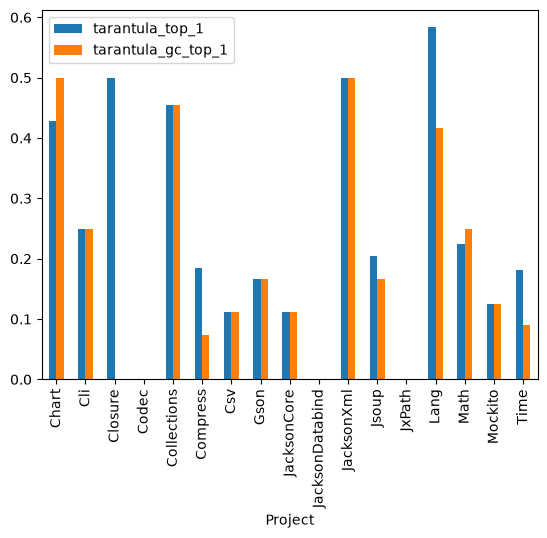

In [77]:
df.drop(columns=["Bug ID"]).groupby("Project").mean()[['tarantula_top_1', 'tarantula_gc_top_1']].plot.bar()

<Axes: xlabel='Project'>

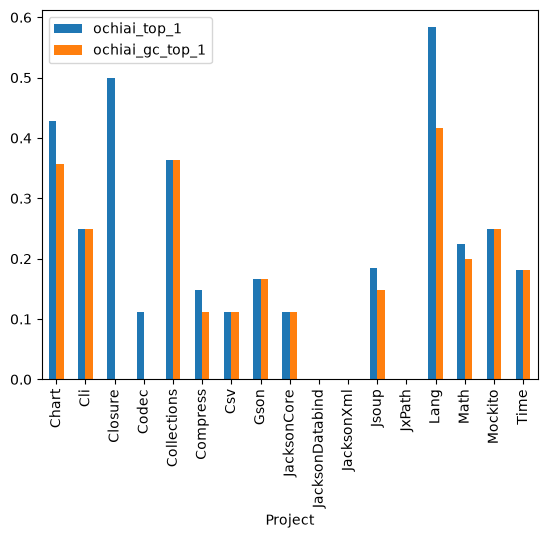

In [79]:
df.drop(columns=["Bug ID"]).groupby("Project").mean()[['ochiai_top_1', 'ochiai_gc_top_1']].plot.bar()

<Axes: xlabel='Project'>

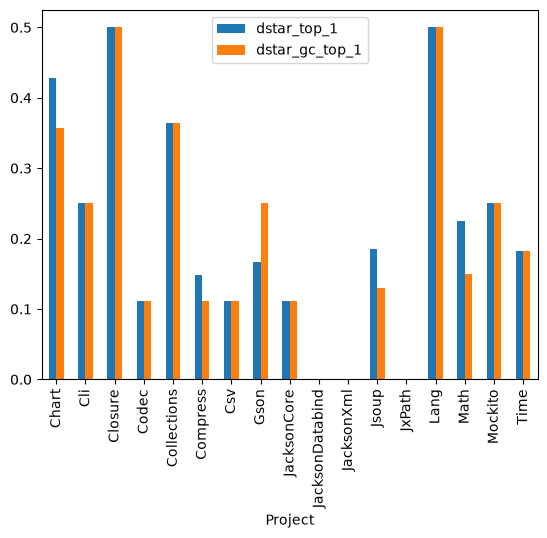

In [80]:
df.drop(columns=["Bug ID"]).groupby("Project").mean()[['dstar_top_1', 'dstar_gc_top_1']].plot.bar()

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_side_by_side_ranks(df: pd.DataFrame, project_name: str, approach: str = 'tarantula') -> None:
    """
    Plots a side-by-side bar chart of Standard vs GC ranks for each Bug ID in a project.
    
    Args:
        df: The flattened dataframe (e.g., from results_topk.csv)
        project_name: The name of the project (e.g., 'Math', 'Chart')
        approach: The base approach to compare ('tarantula', 'ochiai', or 'dstar')
    """
    approach = approach.lower()
    base_col = f"{approach}_rank"
    gc_col = f"{approach}_gc_rank"
    
    # 1. Filter for the requested project
    proj_df = df[df['Project'] == project_name].copy()
    if proj_df.empty:
        print(f"No data found for project: {project_name}")
        return
        
    # 2. Convert Bug ID to integer for proper numerical sorting on the X-axis
    proj_df['Bug ID'] = proj_df['Bug ID'].astype(int)
    proj_df = proj_df.sort_values('Bug ID')
    
    # 3. Extract just the columns we need and set Bug ID as the index
    plot_df = proj_df.set_index('Bug ID')[[base_col, gc_col]]
    
    # 4. Create the side-by-side bar plot
    # Using Pandas built-in plot wrapper over matplotlib
    ax = plot_df.plot(
        kind='bar', 
        figsize=(16, 6), 
        width=0.8, 
        color=['#FF7F50', '#4682B4']  # Coral for Standard, SteelBlue for GC
    )
    
    # 5. Styling and labels
    plt.title(f"{approach.capitalize()} vs {approach.capitalize()}_GC Ranks across {project_name} bugs", fontsize=15)
    plt.xlabel("Bug ID", fontsize=12)
    plt.ylabel("Rank (Lower is Better)", fontsize=12)
    
    # Custom legend names
    plt.legend(["Standard Rank", "Graph Cut (GC) Rank"], loc="upper left")
    
    # Rotate the Bug ID labels so they don't overlap if there are many bugs
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# df = pd.read_csv('results_topk.csv')

# Plot Tarantula comparison for Math


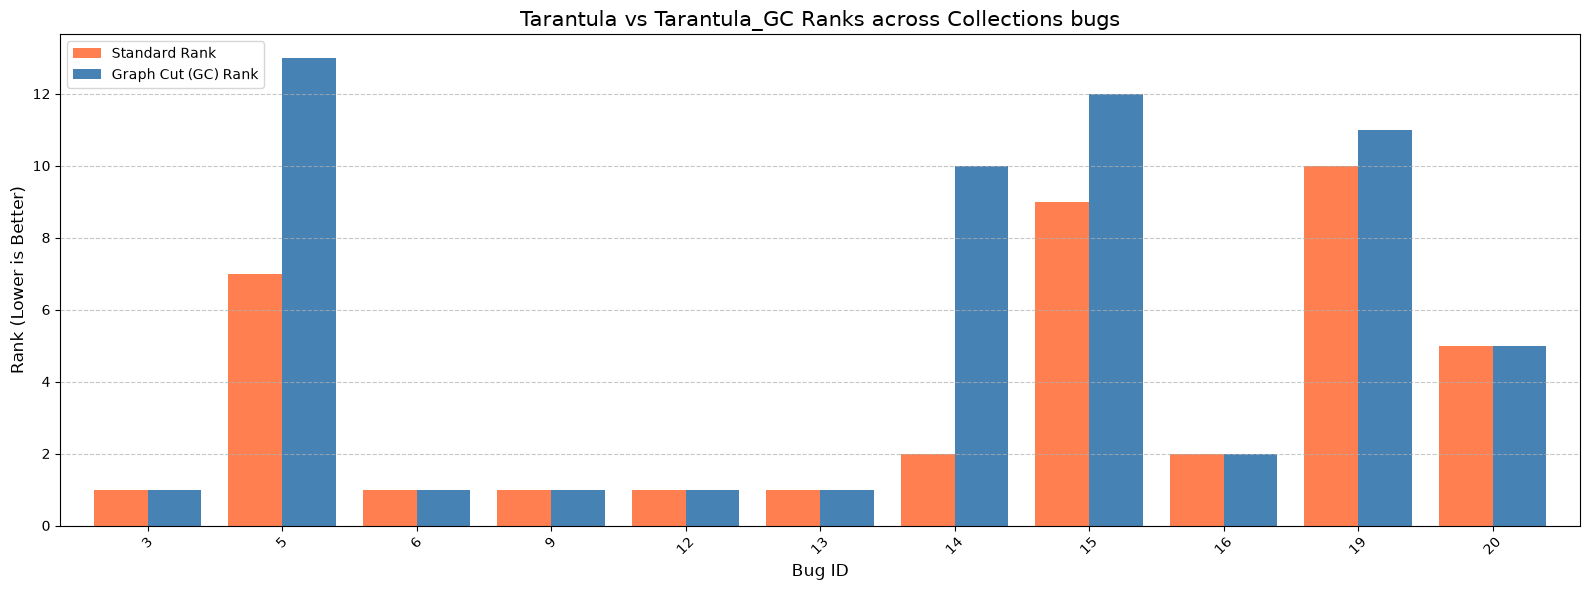

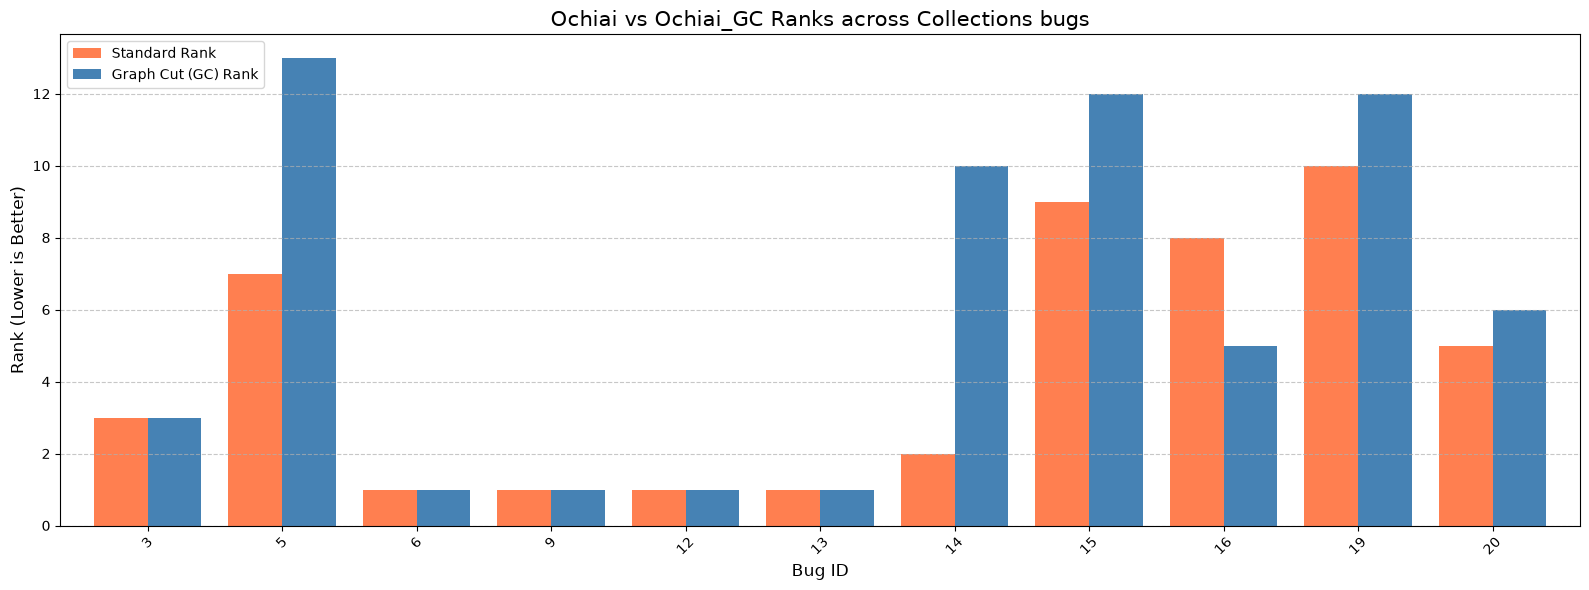

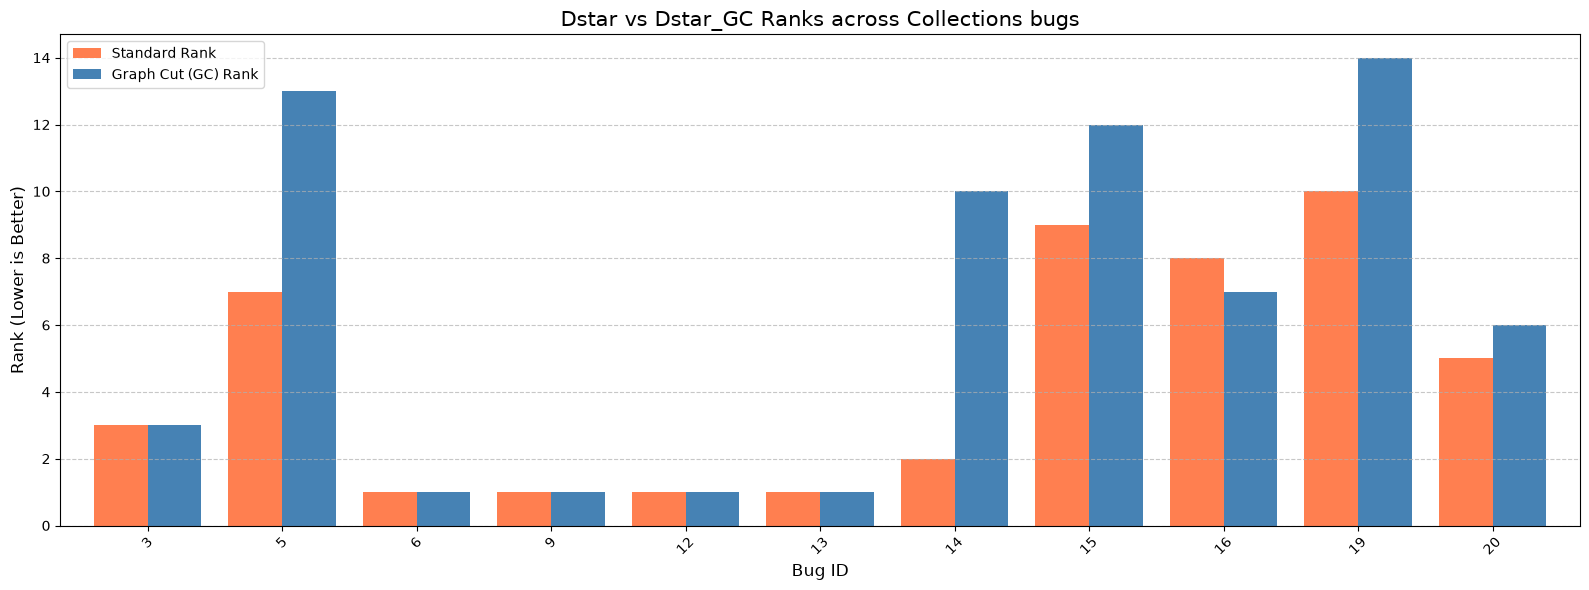

In [76]:
project = "Collections"
plot_side_by_side_ranks(df, project_name=project, approach='tarantula')
plot_side_by_side_ranks(df, project_name=project, approach='ochiai')
plot_side_by_side_ranks(df, project_name=project, approach='dstar')


In [ ]:
import matplotlib.pyplot as plt

cols = ['tarantula_top_1', 'tarantula_gc_top_1']

ax = df[cols].sum().plot(kind='bar', figsize=(6, 4))

ax.set_ylabel("Counts")
ax.set_xlabel("Method")
ax.set_title("Top-1 Success Count")
ax.set_xticklabels(["Tarantula", "Tarantula + GC"], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

cols = ['dstar_top_1', 'dstar_gc_top_1']

ax = df[cols].sum().plot(kind='bar', figsize=(6, 4))

ax.set_ylabel("Counts")
ax.set_xlabel("Method")
ax.set_title("Top-1 Success Count")
ax.set_xticklabels(["D-star", "D-star + GC"], rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

cols = ['ochiai_top_1', 'ochiai_gc_top_1']

ax = df[cols].sum().plot(kind='bar', figsize=(6, 4))

ax.set_ylabel("Counts")
ax.set_xlabel("Method")
ax.set_title("Top-1 Success Count")
ax.set_xticklabels(["D-star", "D-star + GC"], rotation=0)

plt.tight_layout()
plt.show()